# Alumnos:
 - Anastasiya Ruzhytska Ruzhytska
 - Rubén Serna Muñoz

## 1) Reproducibilidad, rutas y versiones

In [1]:
SEED = 42
from pathlib import Path
BASE_DIR = Path('./')

import numpy as np
np.random.seed(SEED)

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import platform
import importlib.metadata as imp
from scipy.stats import boxcox

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, backtesting_forecaster
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


sns.set_style("darkgrid")
sns.set_context("poster")

print(f'Python Version == {platform.python_version()}')
paquetes =['matplotlib','numpy','pandas','seaborn','scipy','skforecast']
for paq in paquetes:
    print(f'{paq} == {imp.version(paq)}')
print(f'OS ==', platform.platform())

Python Version == 3.13.9
matplotlib == 3.10.7
numpy == 2.3.4
pandas == 2.3.3
seaborn == 0.13.2
scipy == 1.16.2
skforecast == 0.19.1
OS == Windows-11-10.0.26100-SP0


# Introducción

En este trabajo se aborda el problema de la predicción del consumo energético total de un barrio a partir de datos históricos horarios comprendidos entre los años 2014 y 2022. El objetivo principal es desarrollar y evaluar modelos predictivos basados en series temporales, utilizando exclusivamente técnicas y metodologías coherentes con las prácticas vistas en la asignatura y haciendo uso de la librería skforecast.

En primer lugar, se ha llevado a cabo un preprocesamiento exhaustivo de los datos, que incluye la construcción del índice temporal, la detección y corrección de valores erróneos, el tratamiento de valores perdidos y la verificación de la frecuencia horaria de la serie. Posteriormente, se ha realizado un análisis descriptivo básico que permite caracterizar el comportamiento temporal del consumo energético.

A continuación, se han desarrollado modelos predictivos univariantes, utilizando únicamente la serie de energía total, y modelos multivariantes, incorporando variables energéticas exógenas. En ambos casos se han empleado varias técnicas de regresión, un esquema de backtesting temporal con ventana expansiva y un proceso sistemático de ajuste de hiperparámetros mediante búsqueda en parrilla.

Finalmente, se han comparado los resultados obtenidos, analizando la evolución del error con el horizonte de predicción y la importancia de las variables explicativas, y se han extraído conclusiones sobre el modelo más adecuado para la predicción del consumo energético.


## Carga y exploración de datos
Se cargan los datos en archivos `Datos_Energia.csv` y `Datos_Climaticos.csv`.

In [2]:
energia = pd.read_csv(BASE_DIR / 'Datos_Energia.csv')

display(energia.head())

,Año,Mes,Día,Hora,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
0,2014,1,1,0,2,21294.33,2.39,8098.10352,876.28229,30268.37288,18880.0
1,2014,1,1,1,2,21190.46,1.95,7312.22987,873.35158,29377.43704,18320.0
2,2014,1,1,2,2,21537.07,4.29,7305.86410,911.45081,29752.56792,18560.0
3,2014,1,1,3,2,21688.66,9.65,7573.82433,870.42087,30130.62951,18790.0
4,2014,1,1,4,2,23044.40,10.19,7462.96849,946.61933,31455.31043,19620.0


# Rango fechas
Se convierten los datos de hora, dia, mes y año a fechas y se eliminan las columnas correspondientes.

In [3]:
energia['fecha'] = pd.to_datetime({
    'year':  energia['Año'],
    'month': energia['Mes'],
    'day':   energia['Día'],
    'hour':  energia['Hora']
})
energia.set_index('fecha', inplace=True)

display(energia)

,Año,Mes,Día,Hora,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
fecha,,,,,,,,,,,
2014-01-01 00:00:00,2014,1,1,0,2,21294.33,2.39,8098.10352,876.28229,30268.37288,18880.0
2014-01-01 01:00:00,2014,1,1,1,2,21190.46,1.95,7312.22987,873.35158,29377.43704,18320.0
2014-01-01 02:00:00,2014,1,1,2,2,21537.07,4.29,7305.86410,911.45081,29752.56792,18560.0
2014-01-01 03:00:00,2014,1,1,3,2,21688.66,9.65,7573.82433,870.42087,30130.62951,18790.0
2014-01-01 04:00:00,2014,1,1,4,2,23044.40,10.19,7462.96849,946.61933,31455.31043,19620.0
...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 19:00:00,2022,12,31,19,5,15684.46,1.65,15884.38982,2464.72711,34031.40452,21220.0
2022-12-31 20:00:00,2022,12,31,20,5,15471.84,1.66,15171.98630,2496.96492,33137.53797,20670.0
2022-12-31 21:00:00,2022,12,31,21,5,15121.29,1.75,14711.04828,2526.27202,32357.96911,20180.0


# Comprobación de integriadad de fechas
Se comprueba si tenemos todo el rango de horas y fechas en el intervalo

In [4]:
fechas_esperadas_energia =  pd.date_range(start=energia.index.min(), end=energia.index.max(), freq='D')
fechas_perdidas_energia = fechas_esperadas_energia.difference(energia.index)
print(f'Número de fechas faltantes en datos de Energía: {len(fechas_perdidas_energia)}')

Número de fechas faltantes en datos de Energía: 0


# Datos faltantes
Se comprueba si faltan datos en las series, y se muetran.

In [5]:
filas_con_algún_nulo_energia = energia[energia.isnull().any(axis=1)]
display(filas_con_algún_nulo_energia)
display(energia.isnull().sum())

,Año,Mes,Día,Hora,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
fecha,,,,,,,,,,,
2016-03-23 16:00:00,2016,3,23,16,2,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-21 08:00:00,2021,4,21,8,2,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-21 09:00:00,2021,4,21,9,2,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 19:00:00,2021,5,18,19,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 20:00:00,2021,5,18,20,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 21:00:00,2021,5,18,21,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 22:00:00,2021,5,18,22,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-18 23:00:00,2021,5,18,23,1,NaN,NaN,NaN,NaN,NaN,NaN
2021-05-19 00:00:00,2021,5,19,0,2,NaN,NaN,NaN,NaN,NaN,NaN


Año                     0
Mes                     0
Día                     0
Hora                    0
Día de la semana        0
Electricidad (kW)      17
Fotovoltaica (kW)      17
Refrigeración (kW)     17
Calefacción (kWh)      17
Energía total (kWh)    17
Emisión (kg CO₂)       17
dtype: int64

# Analisis de los datos

Se muestran las gráficas de los datos para detectar posibles fallos.
Mostramos cada varialbe en todo el rango de datos.
Como se puede ver, observan outliers.

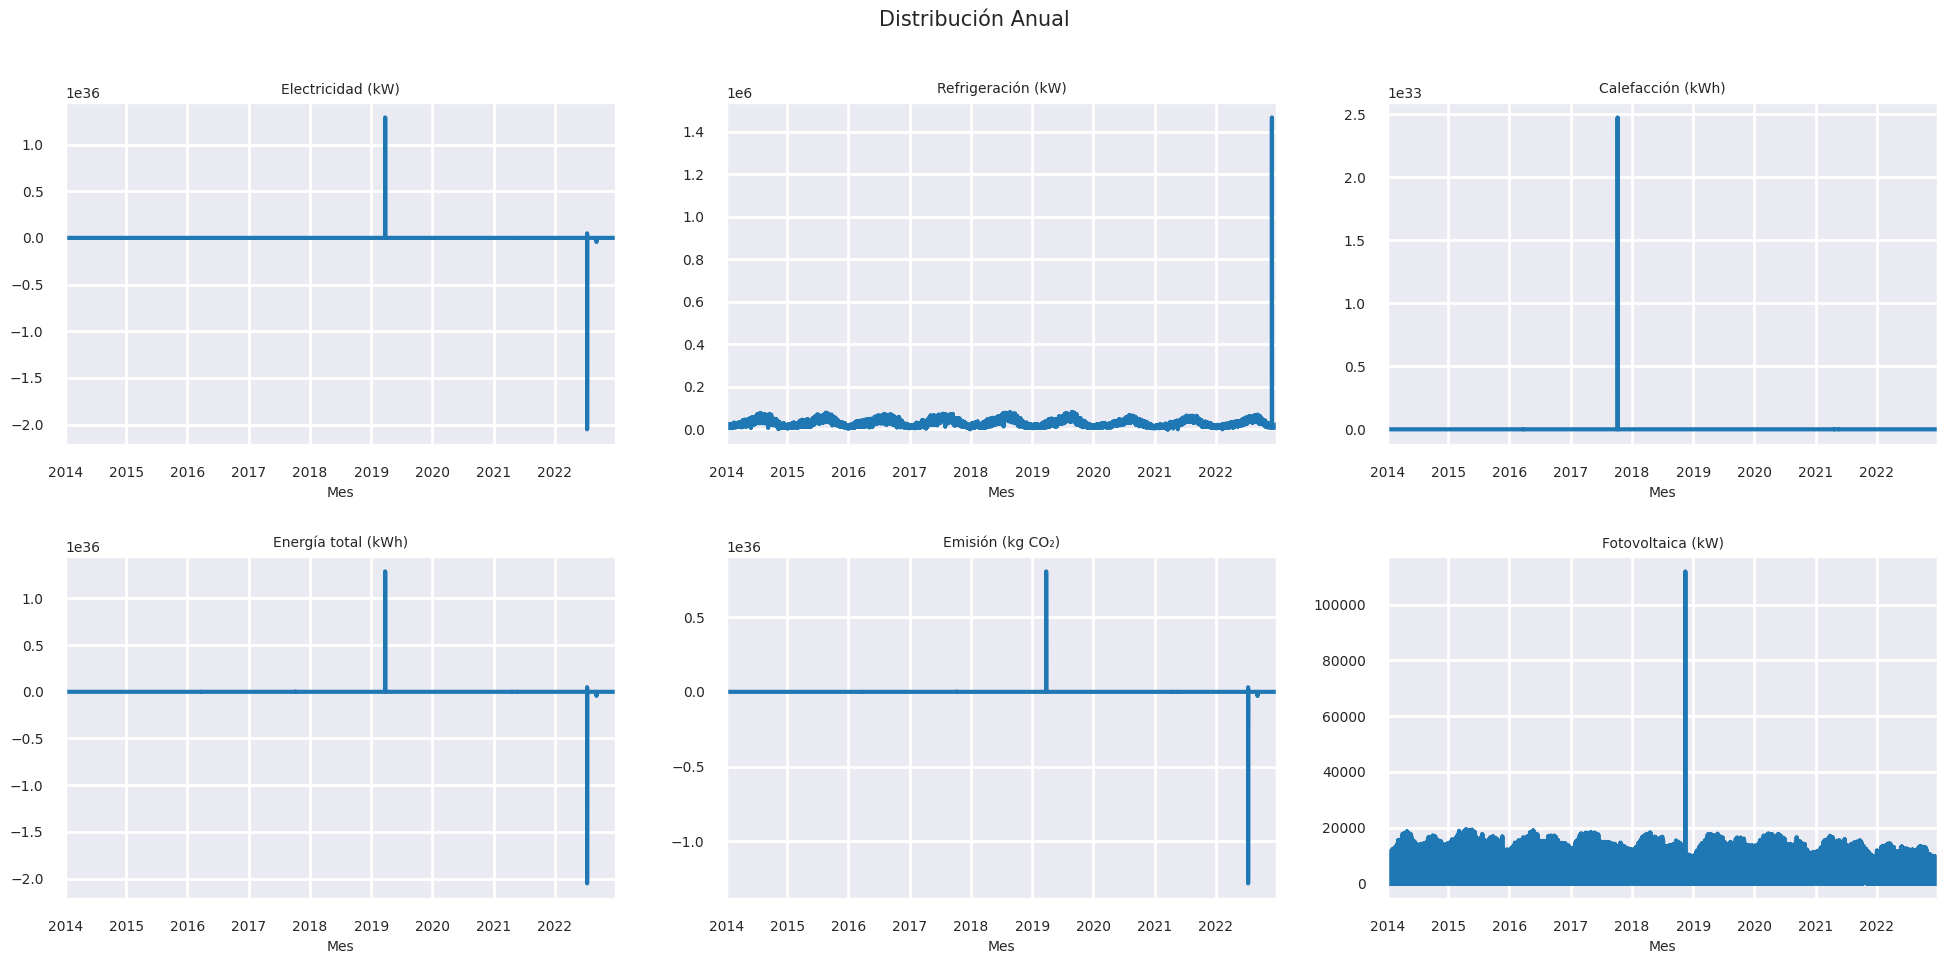

In [6]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
columnas_energia = ['Electricidad (kW)', 'Refrigeración (kW)','Calefacción (kWh)', 'Energía total (kWh)', 'Emisión (kg CO₂)']
columnas_energia_todas = columnas_energia.copy()
columnas_energia_todas.append('Fotovoltaica (kW)')
anyos = range(2014, 2023)


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(columnas_energia_todas):
    ax = axes[i]
    energia[col].plot(ax=ax,figsize=[20, 10])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Mes", fontsize=10)
    ax.set_ylabel("")


# Título general de la figura
fig.suptitle(f"Distribución Anual", fontsize=15)
fig.tight_layout()
plt.show()

Seguidamente analizamos los datos con boxplot para ver estos outlier de forma mas concreta, para ello mostramos los datos por año, agrupados por meses, salvo la Fotovoltaica en la que se muestra por horas.

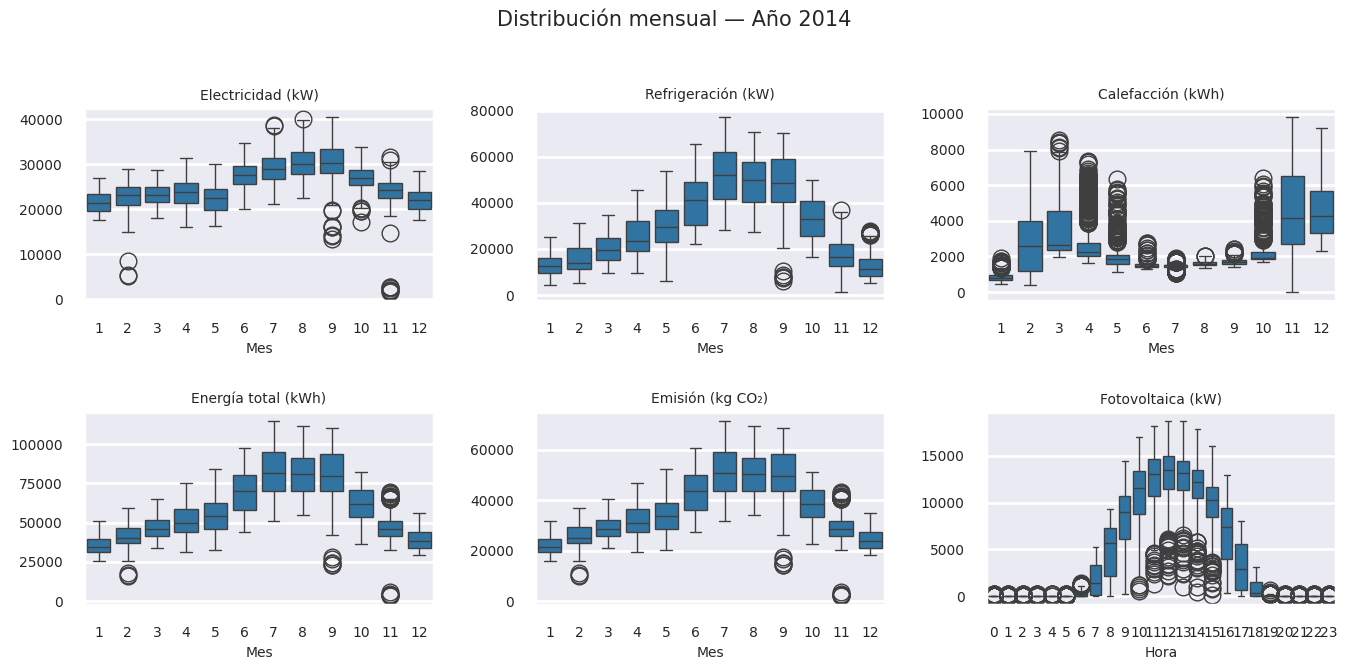

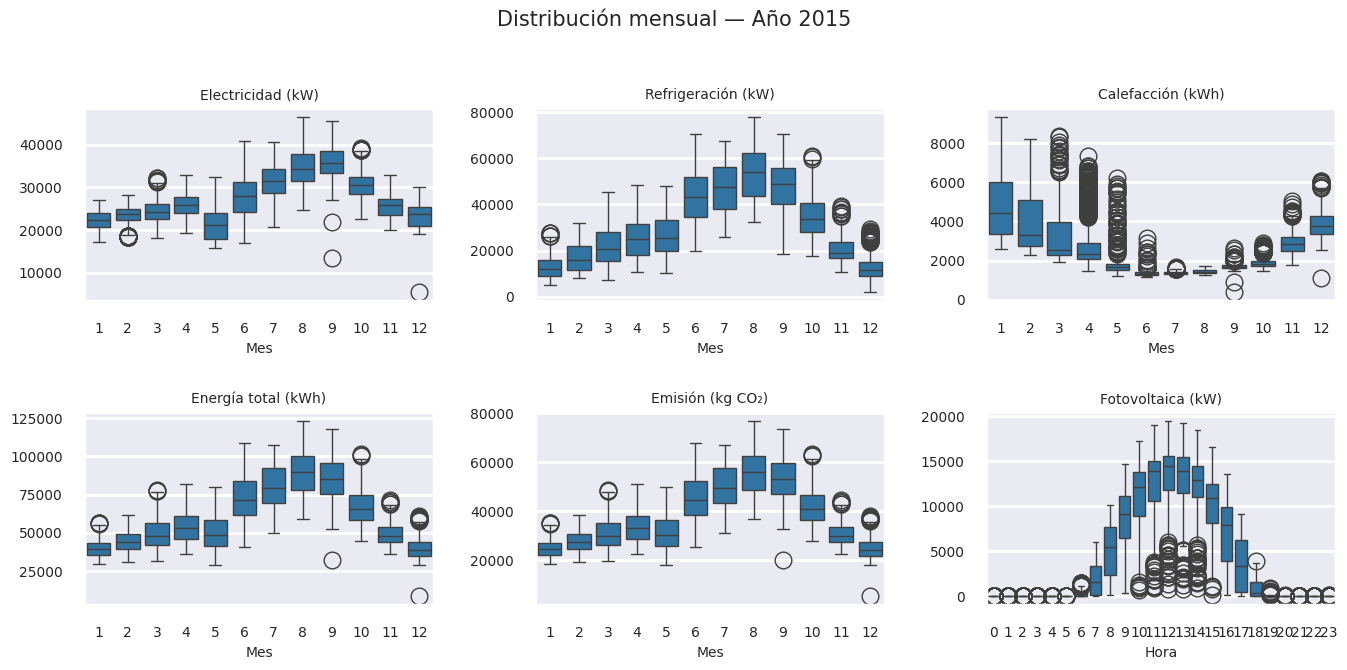

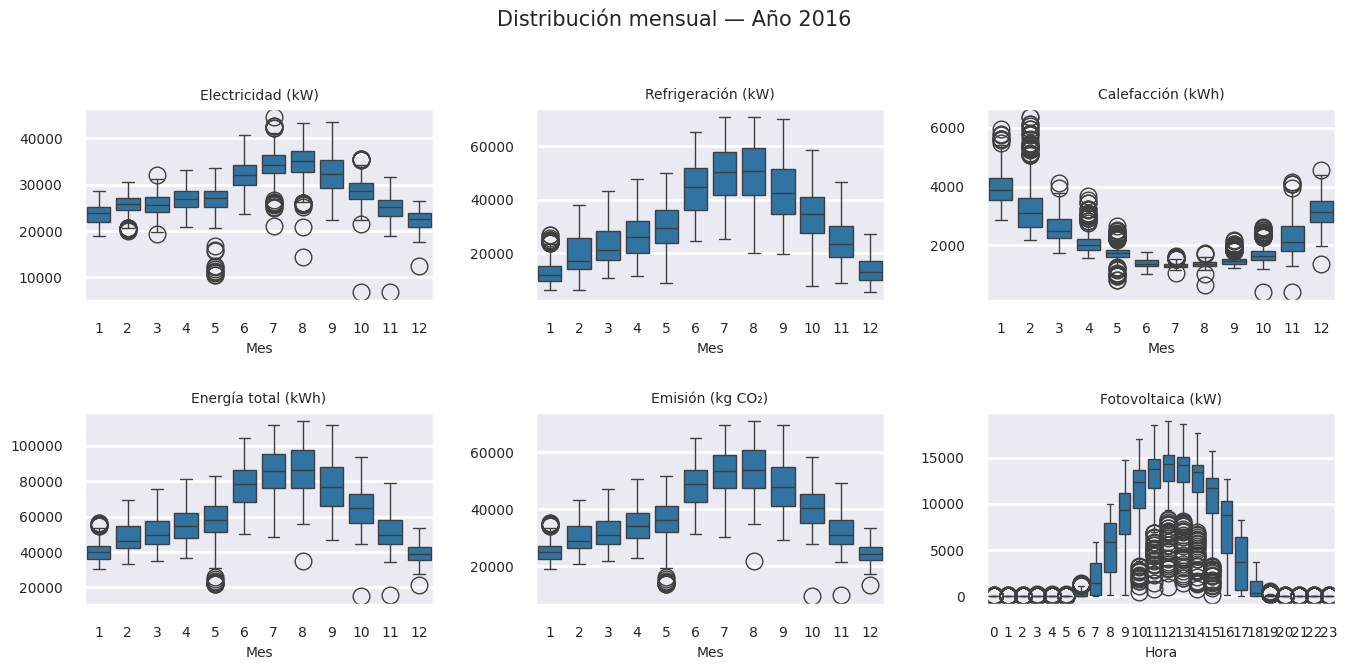

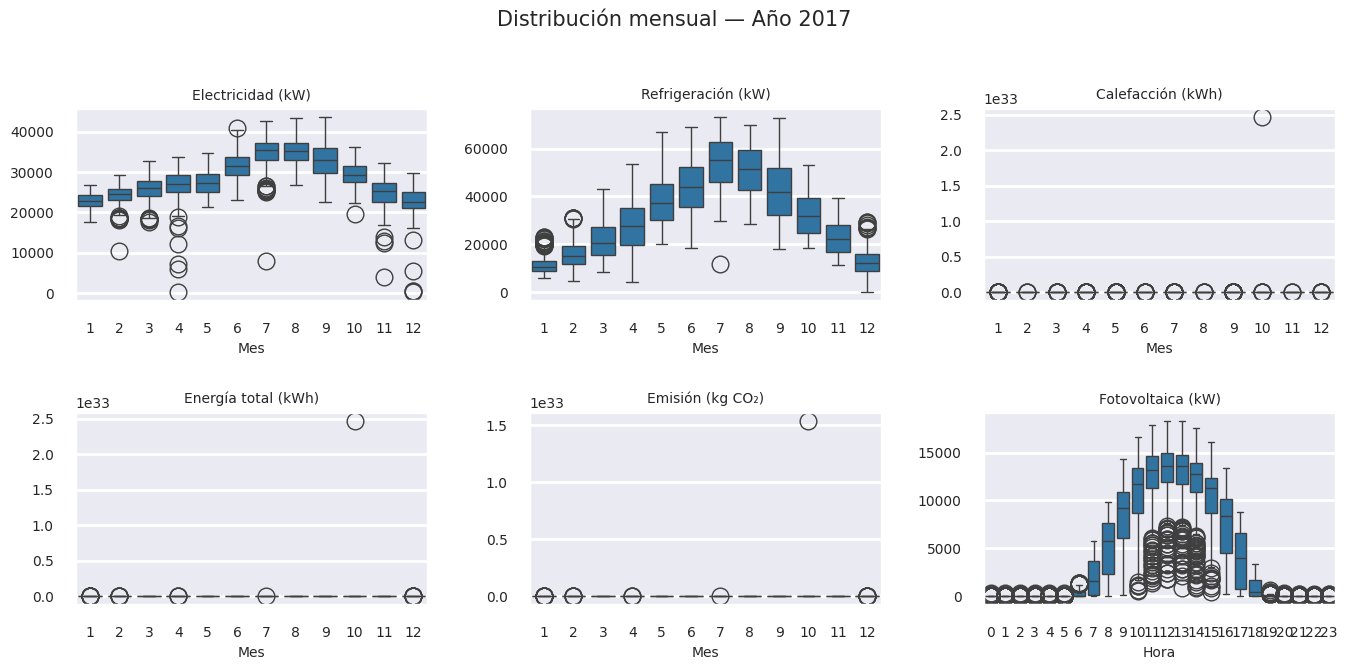

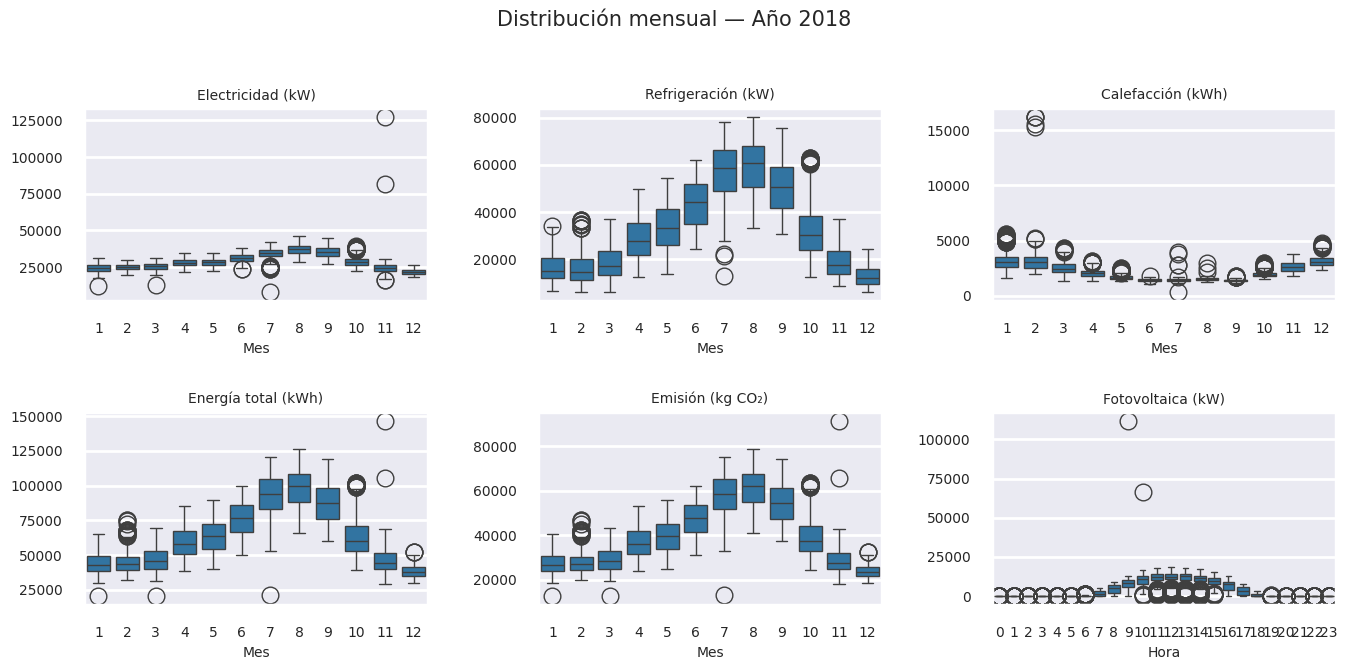

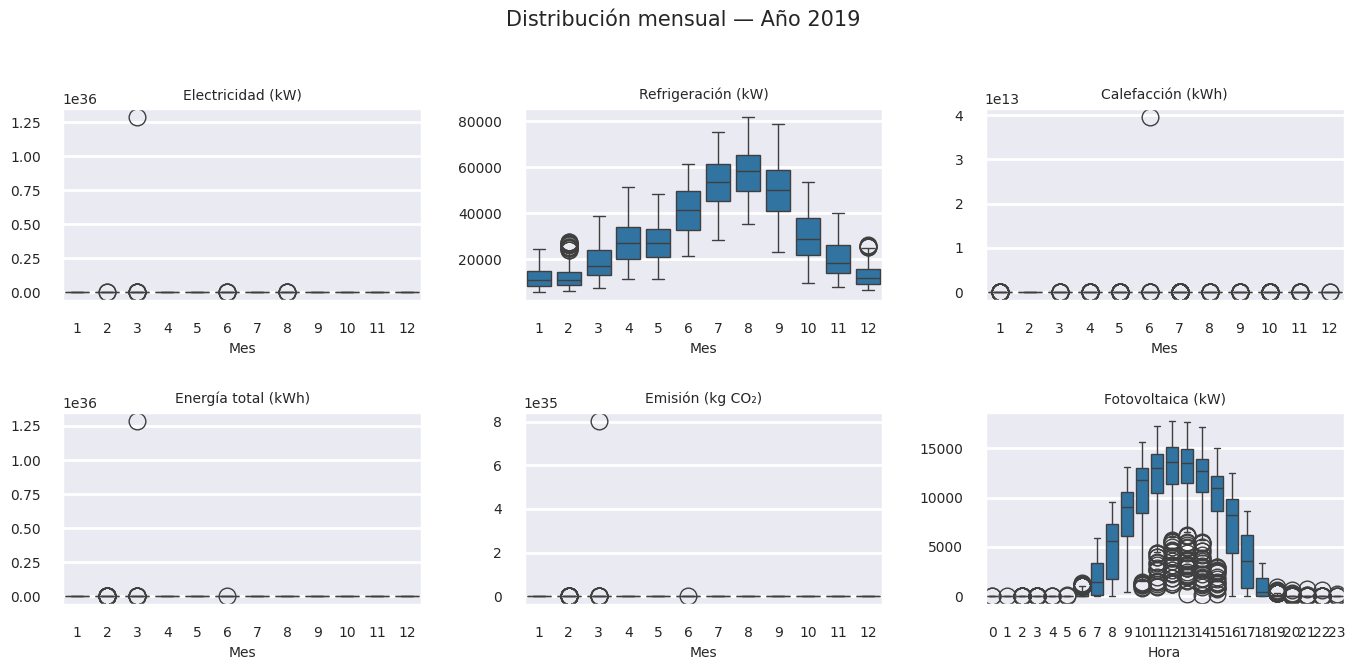

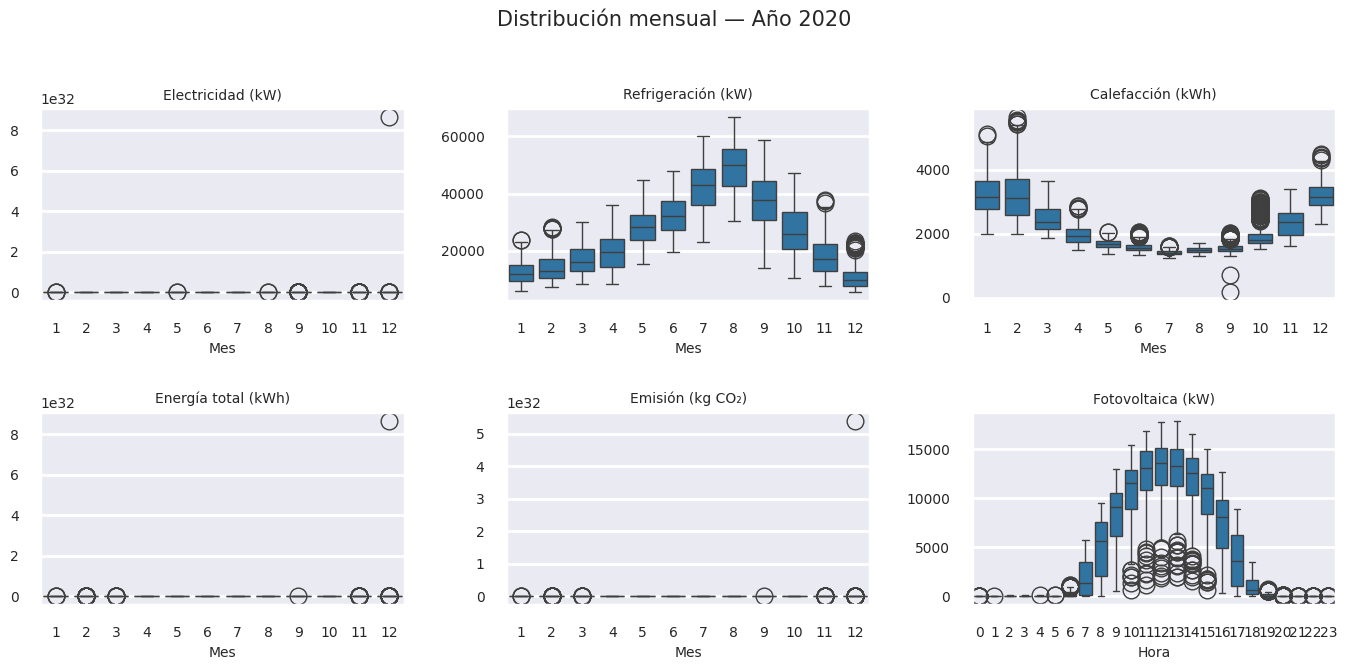

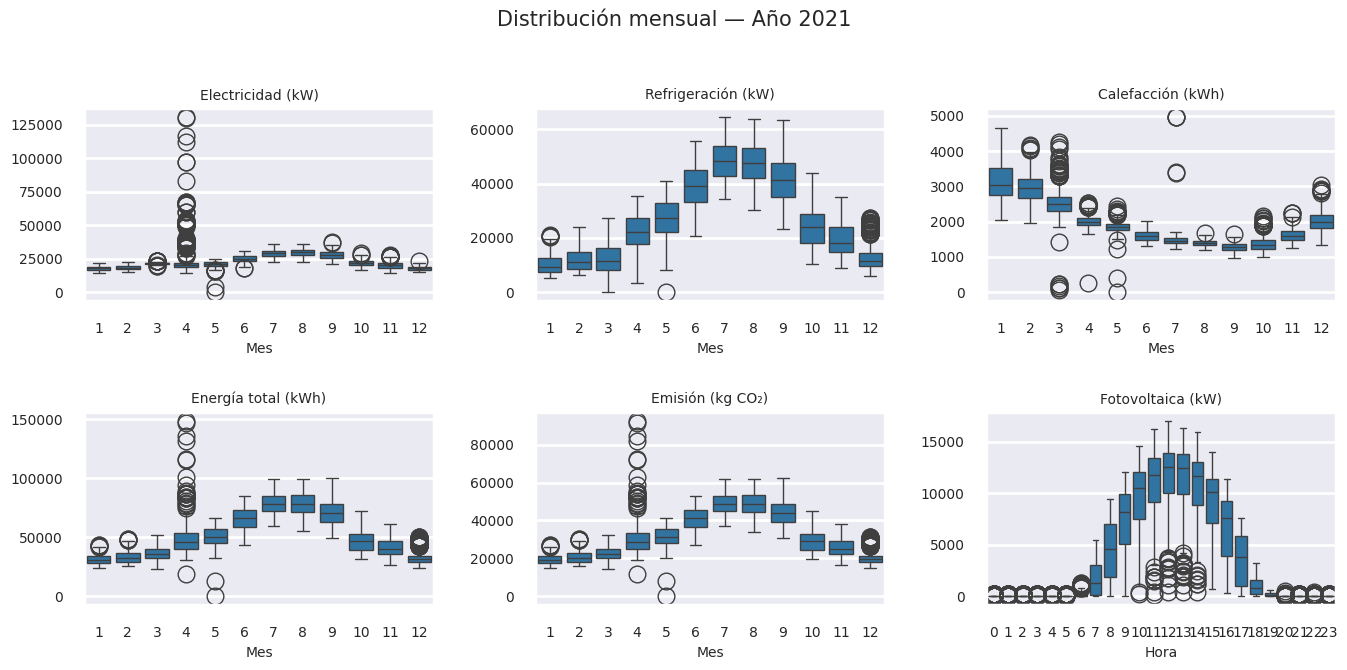

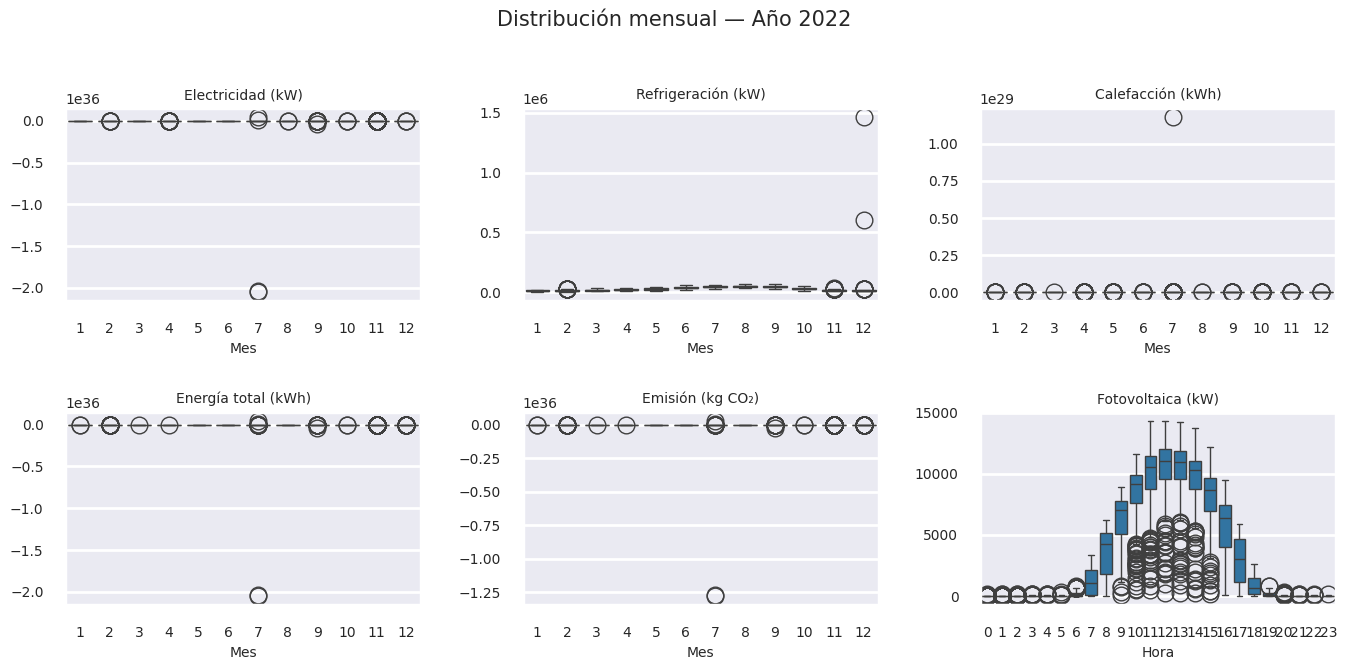

In [7]:
for y in anyos:
    datos = energia.loc[energia.index.year == y]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
    axes = axes.flatten()
    
    for i, col in enumerate(columnas_energia):
        ax = axes[i]
        sns.boxplot(x='Mes', y=col, data=datos, ax=ax, whis=1.5, showfliers=True)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Mes", fontsize=10)
        ax.set_ylabel("")
    ax=axes[-1]
    sns.boxplot(x='Hora', y='Fotovoltaica (kW)', data=datos, ax=ax, whis=1.5, showfliers=True)
    ax.set_title('Fotovoltaica (kW)', fontsize=10)
    ax.set_xlabel("Hora", fontsize=10)
    ax.set_ylabel("")
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()

Hacemos lo mismo con gráfico de violín.

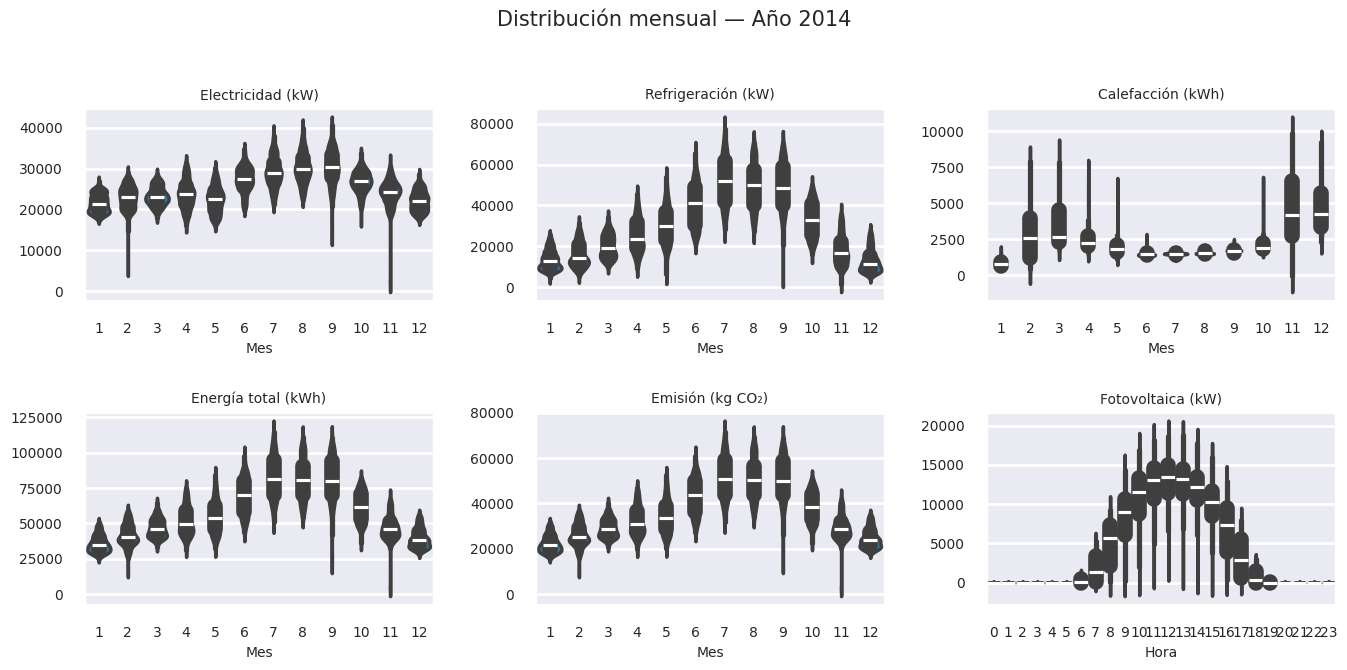

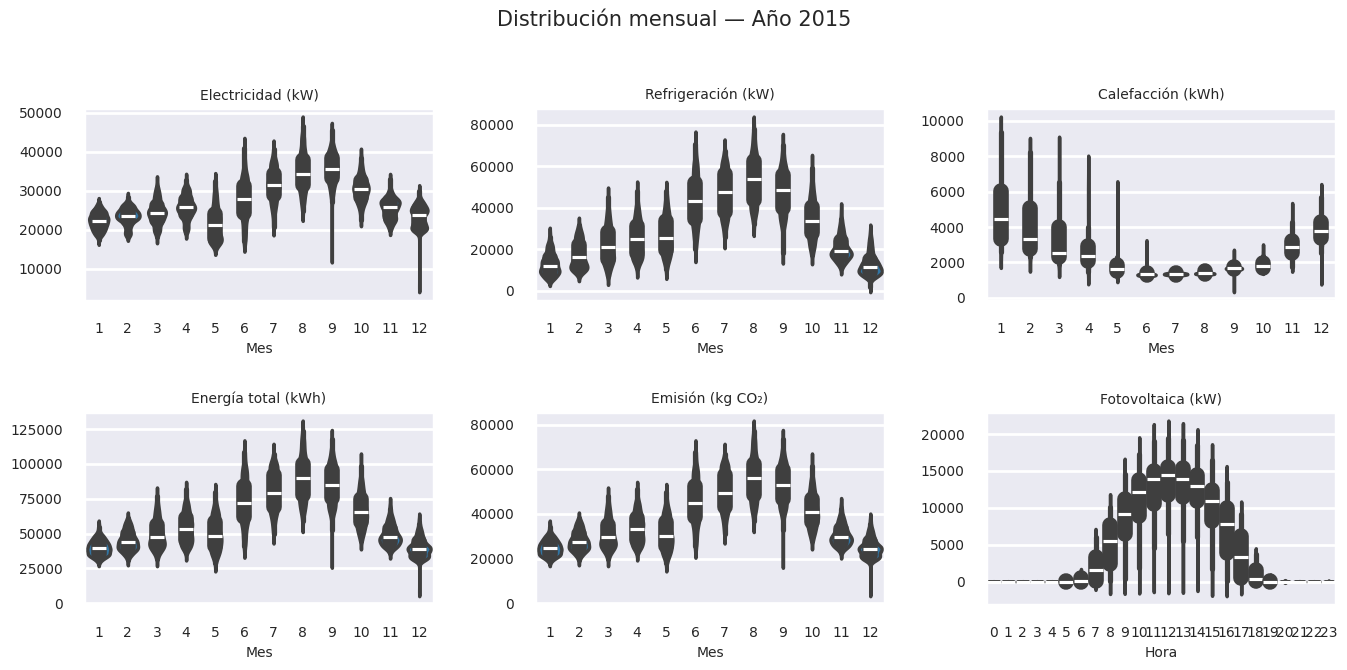

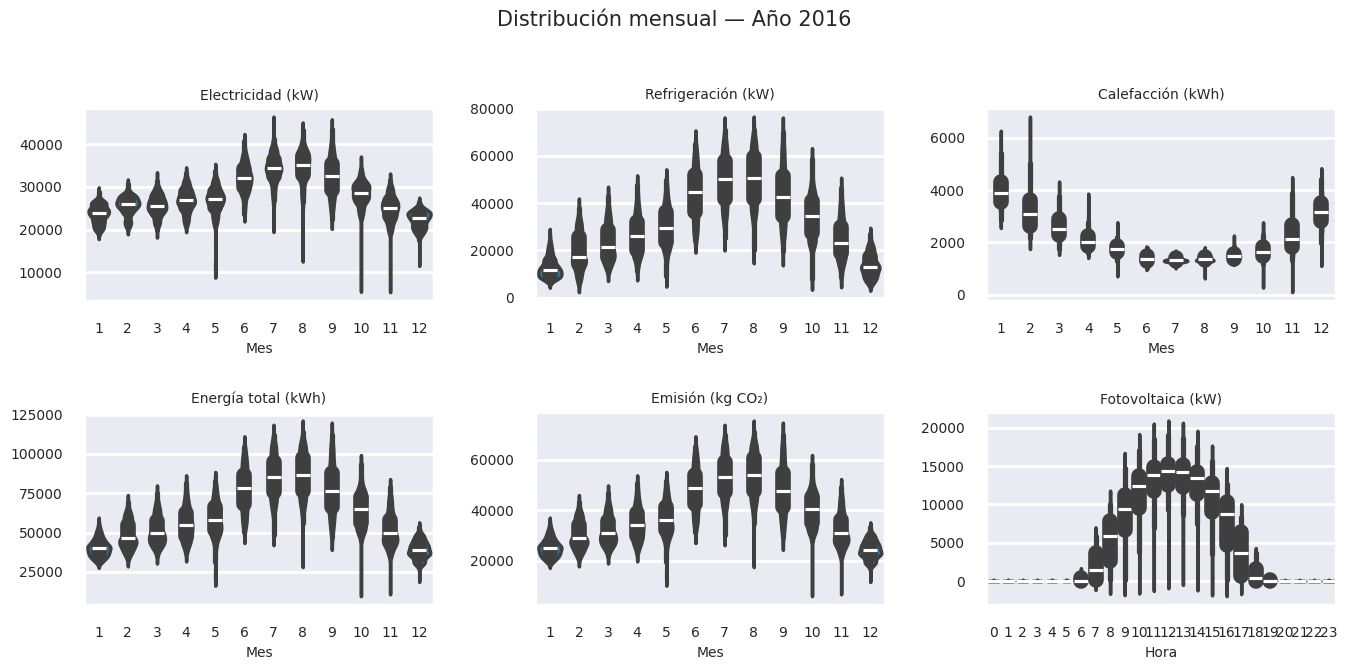

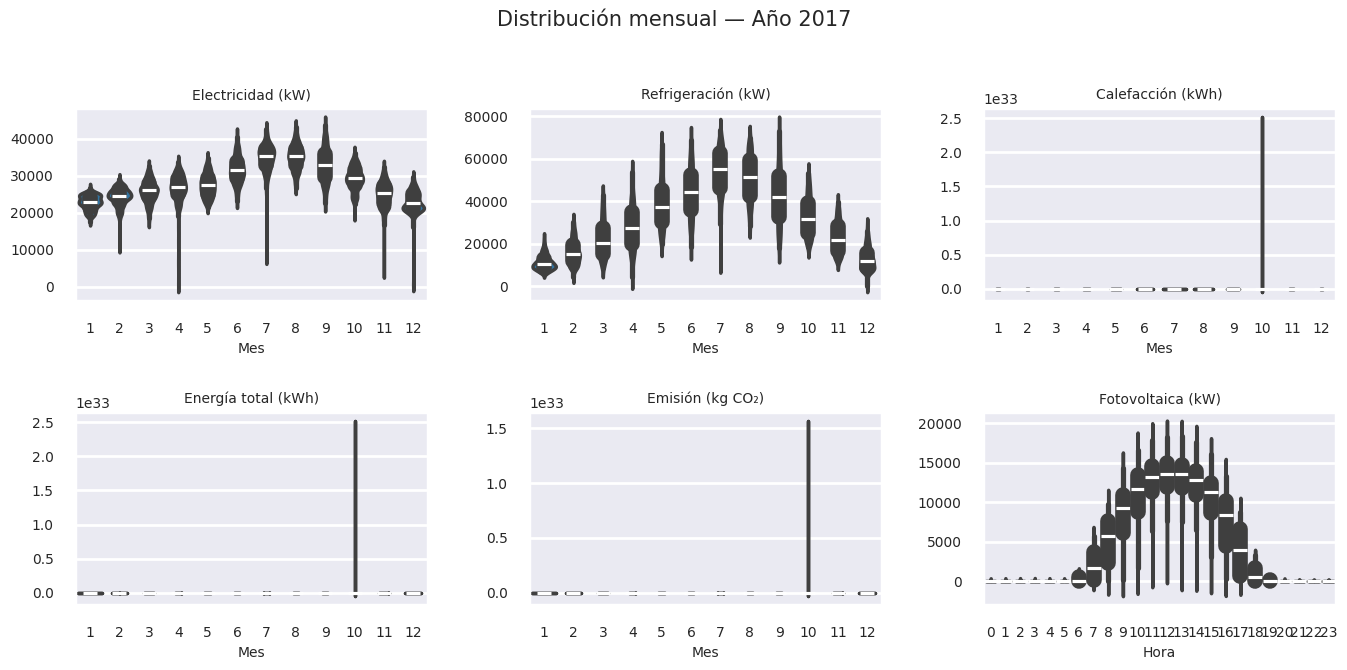

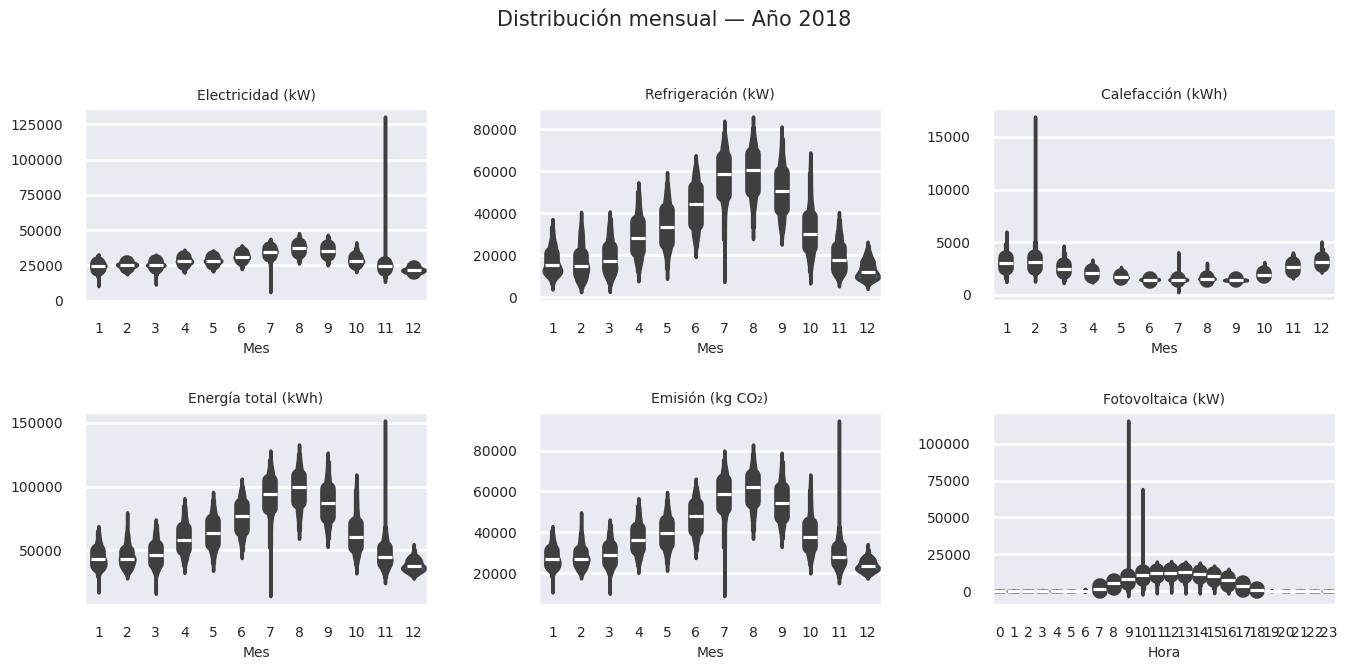

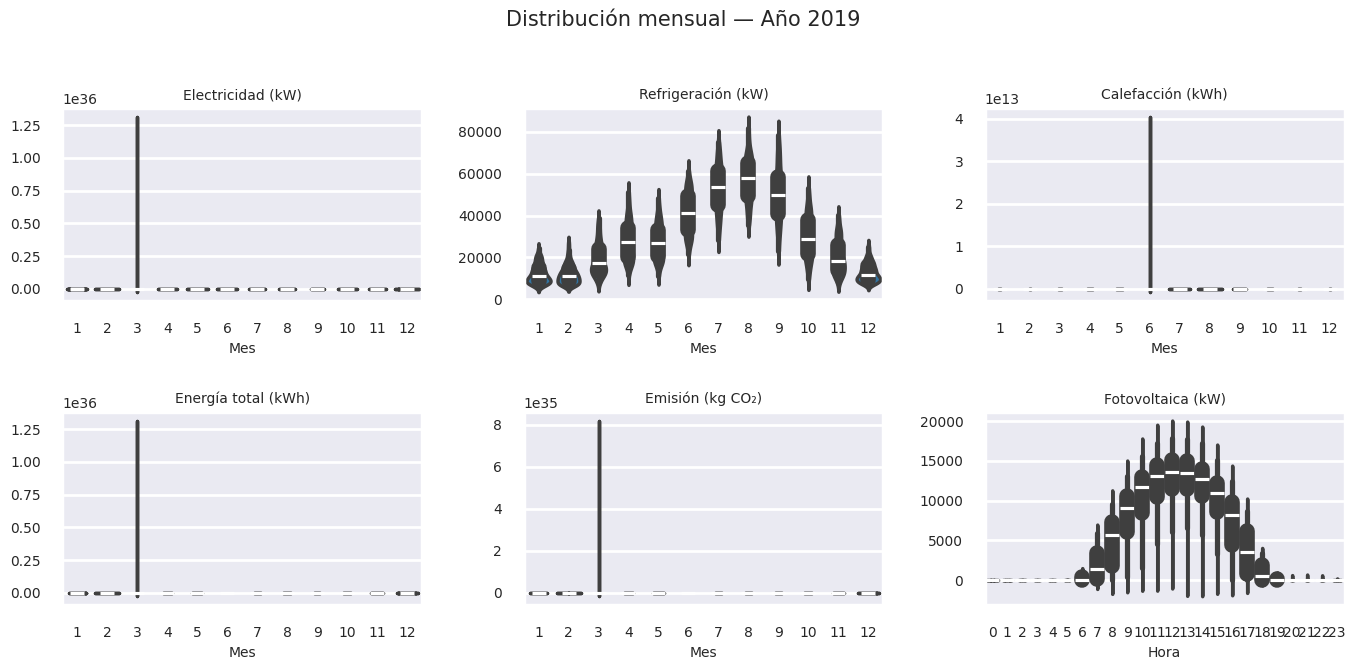

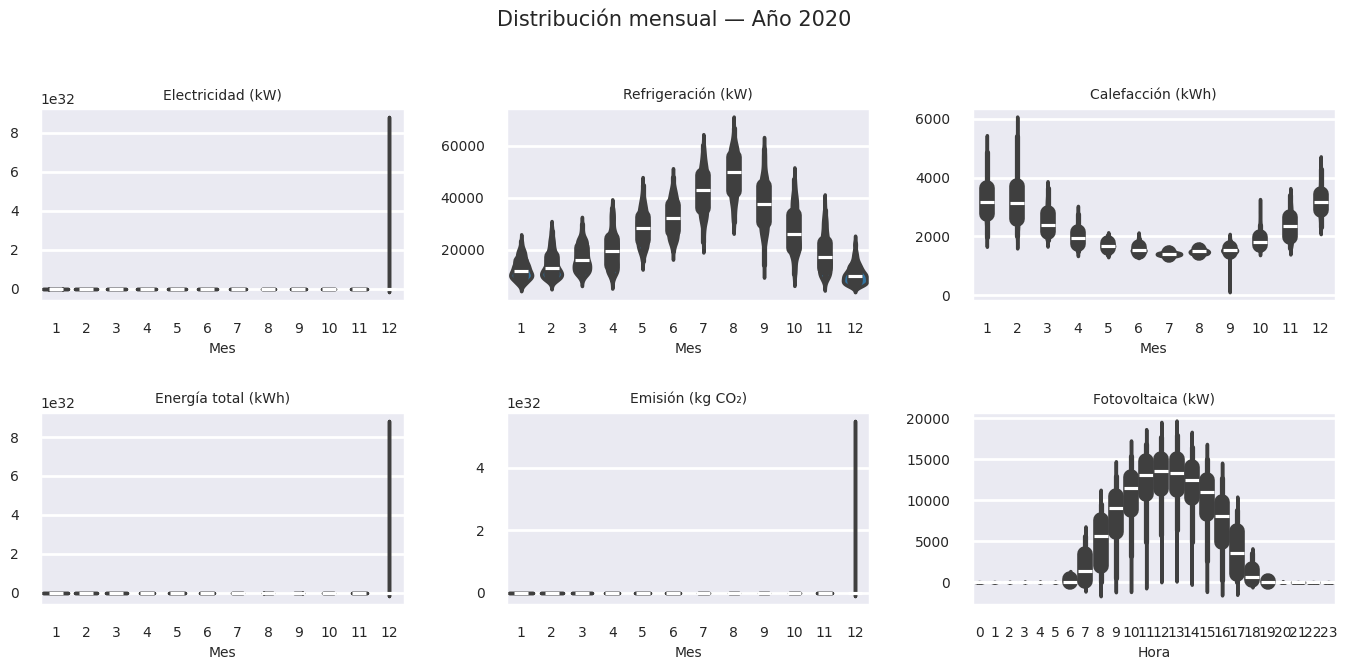

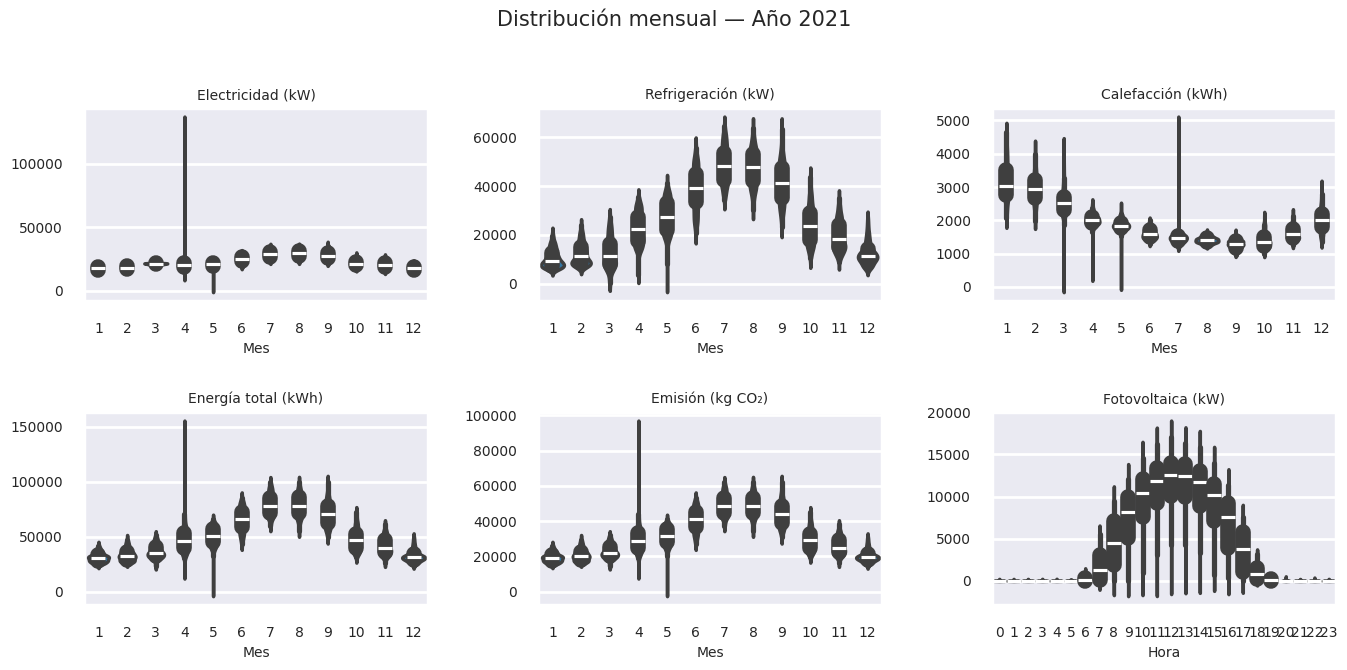

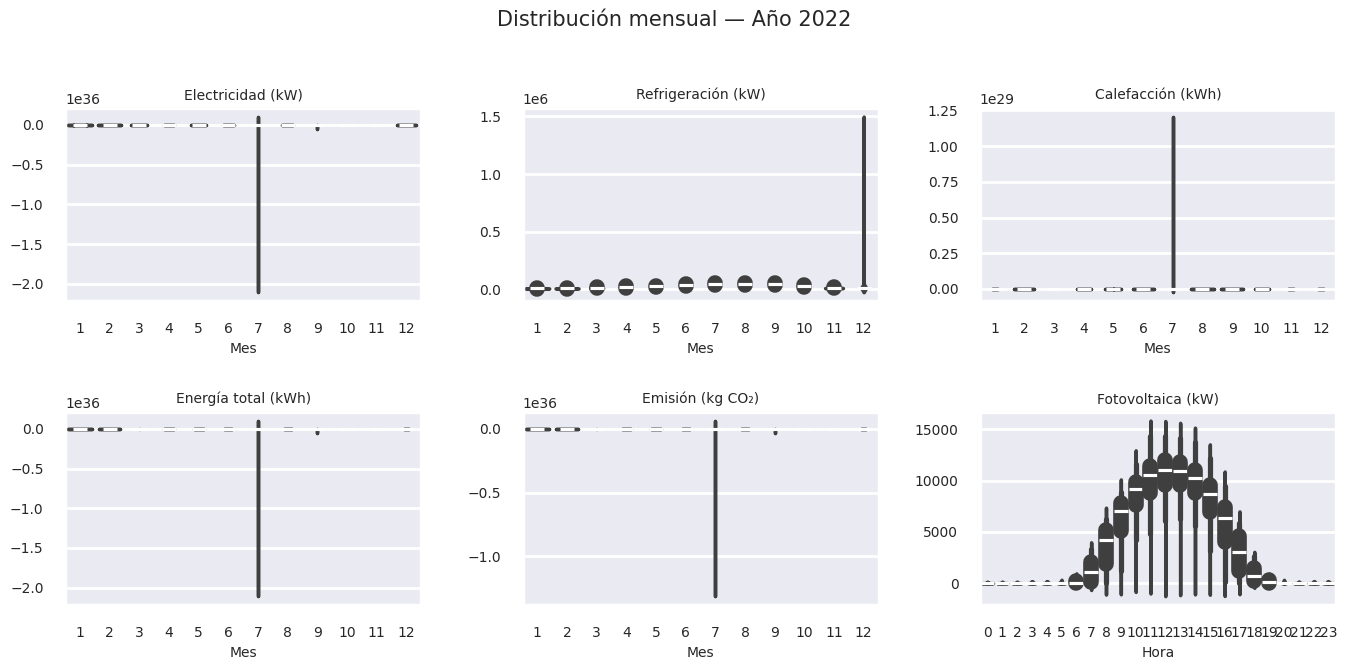

In [8]:
for y in anyos:
    datos = energia.loc[energia.index.year == y]

    # Creamos una sola figura con 6 subplots (2 filas x 3 columnas)
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
    axes = axes.flatten()  # para indexarlos fácilmente
    
    for i, col in enumerate(columnas_energia):
        ax = axes[i]
        sns.violinplot(x='Mes', y=col, data=datos, ax=ax)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Mes", fontsize=10)
        ax.set_ylabel("")
    ax=axes[-1]
    sns.violinplot(x='Hora', y='Fotovoltaica (kW)', data=datos, ax=ax)
    ax.set_title('Fotovoltaica (kW)', fontsize=10)
    ax.set_xlabel("Hora", fontsize=10)
    ax.set_ylabel("")
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()

## Tratamiento de *outliers* e imputación

En este bloque se realiza un control de calidad y tratamiento de outliers en las variables energéticas antes de modelar. El objetivo es reducir el impacto de datos extremos sin destruir la estructura temporal (tendencia/estacionalidad) ni introducir artefactos.

### 1) Columnas tratadas y caso especial: Fotovoltaica (kW)
- variables: pueden tener consumo/producción en cualquier hora.
- Fotovoltaica: tiene una restricción física: por la noche la producción debe ser ≈ 0.  
  Por ello se usa una máscara de horas diurnas (`07:00–20:00`) para evitar interpolaciones “puente” a través de la noche.

### 2) Señalización de inconsistencias (trazabilidad)
Para cada columna se crean banderas:

- `inconsistente_{col}`: marca cualquier punto considerado inválido/anómalo (negativos u outliers).
- `is_imputed_{col}`: marca puntos que han sido imputados tras convertirlos en `NaN`.

Esto permite auditar el proceso y cuantificar qué parte del dataset fue modificada.

### 3) Regla 1: valores negativos → inválidos → `NaN`
Para todas las columnas:

- Se detectan valores negativos con `mask_neg = (s < 0)`.
- Se marcan como inconsistentes y se convierten en `NaN`.

En magnitudes como potencia/energía, valores negativos suelen indicar errores de medida/captura. Se opta por tratarlos como faltantes para imputarlos con un método temporal coherente.

### 4) Regla 2: detección robusta de outliers (mediana + MAD)
Los outliers se detectan con:

- Mediana móvil en ventana de `ventana_horas = 24` (un ciclo diario):
  - `rol_med`: mediana local (robusta a extremos).
  - `resid = s - rol_med`: residuo respecto a la normalidad local.

- MAD (Median Absolute Deviation) sobre el residuo:
  - Se calcula en ventana móvil (con `min_periods` al 50% para estabilidad).
  - Se ajusta con `1.4826` para aproximar una desviación estándar robusta (`mad_adj`).
  - Se define el z-score: `z_rob = resid / mad_adj`.

Luego se marca outlier positivo cuando:
- `z_rob > umbral_k` con `umbral_k = 4.0`.

MAD es menos sensible que la media/desviación típica ante extremos lo que es ideal en series energéticas con picos.
Un umbral alto como 4.0, reduce el riesgo de "recortar" picos reales de demanda, priorizando actuar solo sobre valores claramente anómalos.

### 5) Regla 3: control adicional por percentil alto (winsorización)
Además del criterio MAD, se aplica un segundo criterio:

- Se calcula `q_high = quantile(0.995)` (P99.5).
- Sirve como "red de seguridad" frente a distribuciones pesadas o MAD local inestable.
- Permite controlar picos extremadamente raros manteniendo el resto intacto.
- Se marca outlier si `s > q_high`.
La máscara final de outliers positivos es la unión de ambos criterios:
- `mask_pos = mask_mad_pos OR mask_pct_pos`

### 6) Tratamiento del outlier: winsorización en vez de borrado
Cuando un punto es outlier positivo (`mask_pos`), no se elimina el registro:
- Se marca como inconsistente.
- Se recorta al percentil alto:
  - `s.loc[mask_pos] = min(s.loc[mask_pos], q_high)`

Motivo de winsorizar en lugar de eliminar:
- Preserva la continuidad temporal (no crea huecos artificiales).
- Evita que un extremo erróneo domine el ajuste del modelo.
- Mantiene el orden temporal y el patrón estacional (picos siguen siendo picos, pero acotados).

### 7) Imputación: interpolación temporal "time-aware"
Tras convertir a `NaN` los negativos y aplicar reglas de tratamiento, se rellena con interpolación:

#### 7.1 todos los valores, menos Fotovoltaica: `impute_column()`
Se usa `interpolate(method='time')`:

- Usa la geometría temporal real del índice.
- `limit_direction='both'` rellena hacia delante/atrás si hay soporte.
- `limit_area='inside'` evita extrapolar fuera del rango (más seguro).

#### 7.2 Fotovoltaica: `impute_fotovoltaica()`
Se aplica un tratamiento específico:

1) Horas nocturnas → 0 (`s.loc[~horas_diurnas_mask] = 0.0`)
2) Interpolación solo en horas diurnas (`s.where(horas_diurnas_mask)`)

### 8) Registro de imputaciones (qué se cambió y dónde)
Para cada columna se guardan:

- `inicial_na`: `True` donde el valor quedó en `NaN` antes de imputar.
- `final_na`: `True` donde sigue siendo `NaN` tras imputar.
- Se marca como imputado cualquier punto que era `NaN` y ya no lo es:
  - `is_imputed_{col} |= ((~final_na) & inicial_na)`

In [9]:
columnas_energia_todas = columnas_energia.copy()
columnas_energia_todas.append('Fotovoltaica (kW)')

def impute_column(series: pd.Series) -> pd.Series:
    s =series.copy()
    s = s.interpolate(
        method='time',          # pendiente basada en el tiempo real (segundos)
        limit_direction='both', # rellena hacia dentro y bordes con soporte
        limit_area='inside'     # evita extrapolar fuera de los datos
    )
    return s

def impute_fotovoltaica(series: pd.Series, horas_diurnas_mask: pd.Series) -> pd.Series:
    s = series.copy()
    # Nocturnas = 0 (coherencia física). No tocamos valores diurnos aquí.
    s.loc[~horas_diurnas_mask] = np.float64(0.0)
    # Interpolación solo en diurnas (evita puentes a través de la noche)
    s_diurnas = s.where(horas_diurnas_mask)
    s_diurnas = s_diurnas.interpolate(
        method='time',
        limit_direction='both',
        limit_area='inside'
    )
    # Actualiza únicamente los puntos diurnos interpolados
    s.update(s_diurnas)
    return s

ventana_horas = 24            # mediana/mad sobre 24h
umbral_k = 4.0                # robust z-score: k=4 (más conservador)
percentil_alto = 0.995        # P99.5 para winsorización

horas_diurnas = energia.index.hour.isin(range(7, 20))

for col in columnas_energia_todas:
    # Bandera de inconsistencias
    energia[f"inconsistente_{col}"] = False

    s = energia[col].copy()

    mask_neg = (s < 0)
    energia[f"inconsistente_{col}"] = energia[f"inconsistente_{col}"] | mask_neg
    s.loc[mask_neg] = np.nan

    if col == 'Fotovoltaica (kW)':
        s_dia = s.where(horas_diurnas)
        # Mediana móvil y residuos (diurnas)
        rol_med = s_dia.rolling(window=ventana_horas, center=True,
                                min_periods=int(ventana_horas*0.5)).median()
        resid = s_dia - rol_med

        # MAD robusta (diurnas)
        mad = resid.rolling(window=ventana_horas, center=True,
                            min_periods=int(ventana_horas*0.5)) \
                   .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)

        mad_adj = (1.4826 * mad).replace(0, np.nan)
        z_rob = resid / mad_adj

        mask_mad_pos = (z_rob > umbral_k)            # detectado solo en diurnas (porque z_rob es NaN en noches)
        q_high = s.loc[horas_diurnas].quantile(percentil_alto)  # percentil en diurnas
        mask_pct_pos = (s > q_high) & horas_diurnas             # umbral solo en diurnas

        # Máscara final de outlier positivo (excluye noches)
        mask_pos = (mask_mad_pos.fillna(False)) | (mask_pct_pos.fillna(False))

        # Marca inconsistencias y CAPA al percentil alto (winsorización) solo en diurnas
        energia[f"inconsistente_{col}"] = energia[f"inconsistente_{col}"] | mask_pos
        s.loc[mask_pos] = np.minimum(s.loc[mask_pos], q_high)

        # Re-imputación: SOLO diurnas; noches = 0
        inicial_na = s.isna()
        s_imp = impute_fotovoltaica(s, horas_diurnas)
        final_na = s_imp.isna()
        energia[col] = s_imp
    else:
        # Mediana móvil y residuos
        rol_med = s.rolling(window=ventana_horas, center=True,
                            min_periods=int(ventana_horas*0.5)).median()
        resid = s - rol_med

        # MAD (Median Absolute Deviation)
        mad = resid.rolling(window=ventana_horas, center=True,
                        min_periods=int(ventana_horas*0.5)) \
            .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=False)

        # z-score robusto (evitar división por 0)
        mad_adj = 1.4826 * mad
        mad_adj = mad_adj.replace(0, np.nan)
        z_rob = resid / mad_adj

        mask_mad_pos = z_rob > umbral_k     # solo positivos extremos

        q_high = s.quantile(percentil_alto)
        mask_pct_pos = s > q_high

        # Máscara final (union de criterios)
        mask_pos = (mask_mad_pos.fillna(False)) | (mask_pct_pos.fillna(False))
        energia[f"inconsistente_{col}"] = energia[f"inconsistente_{col}"] | mask_pos
        s.loc[mask_pos] = np.minimum(s.loc[mask_pos], q_high)


        # Re-imputación de los NaN recién creados
        inicial_na = s.isna()
        s_imp = impute_column(s)
        final_na = s_imp.isna()
        energia[col] = s_imp

    # Bandera de imputación (actualizada)
    if f"is_imputed_{col}" not in energia.columns:
        energia[f"is_imputed_{col}"] = False
    energia[f"is_imputed_{col}"] = energia[f"is_imputed_{col}"] | ((~final_na) & inicial_na)

Se muestran los resultados tras el tratamiento de los datos, donde se informa de cuantos valores se han corregido.

In [10]:
print("Corrección de inconsistencias completada.")
for col in columnas_energia_todas:
    inc = int(energia[f"inconsistente_{col}"].sum())
    imp = int(energia[f"is_imputed_{col}"].sum())
    print(f"{col}: inconsistentes corregidos = {inc}, imputados (incluye faltantes previos) = {imp}")

Corrección de inconsistencias completada.
Electricidad (kW): inconsistentes corregidos = 593, imputados (incluye faltantes previos) = 120
Refrigeración (kW): inconsistentes corregidos = 406, imputados (incluye faltantes previos) = 17
Calefacción (kWh): inconsistentes corregidos = 2435, imputados (incluye faltantes previos) = 24
Energía total (kWh): inconsistentes corregidos = 507, imputados (incluye faltantes previos) = 118
Emisión (kg CO₂): inconsistentes corregidos = 507, imputados (incluye faltantes previos) = 118
Fotovoltaica (kW): inconsistentes corregidos = 214, imputados (incluye faltantes previos) = 17


Finalmente mostramos de nuevo el gráfico donde se aprecia la mejora en la información, mostramos tanto los datos por años como el global.

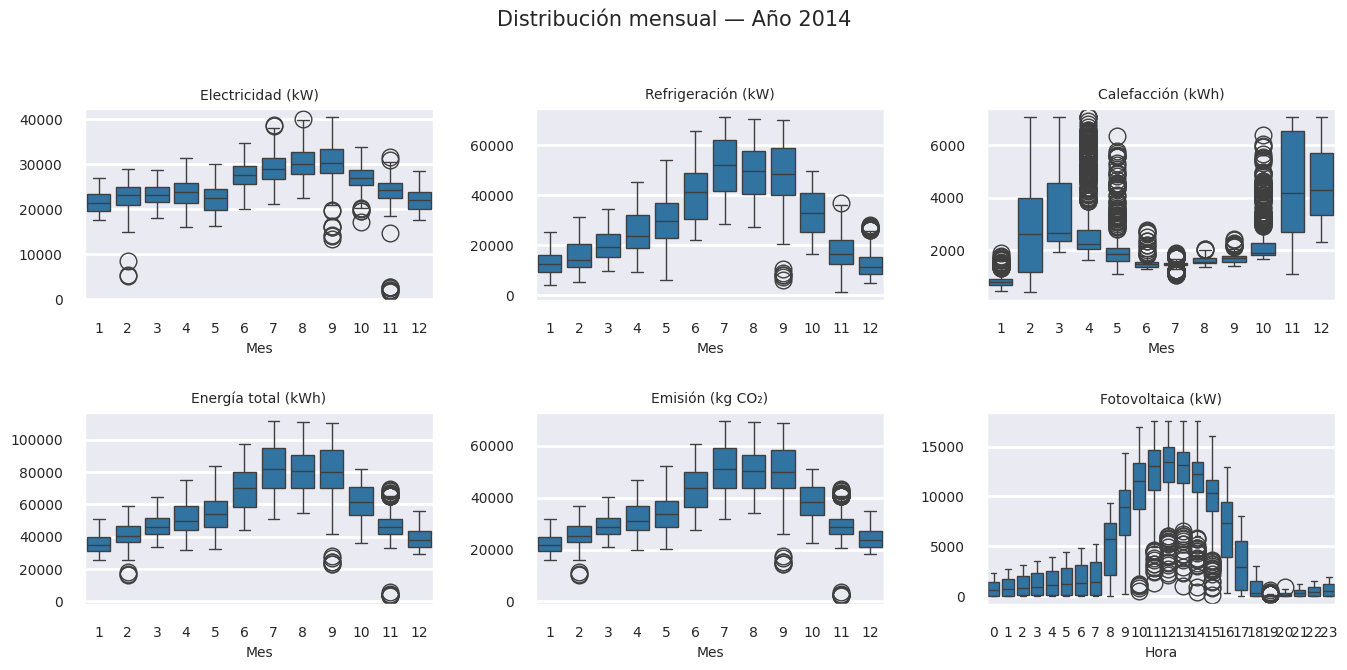

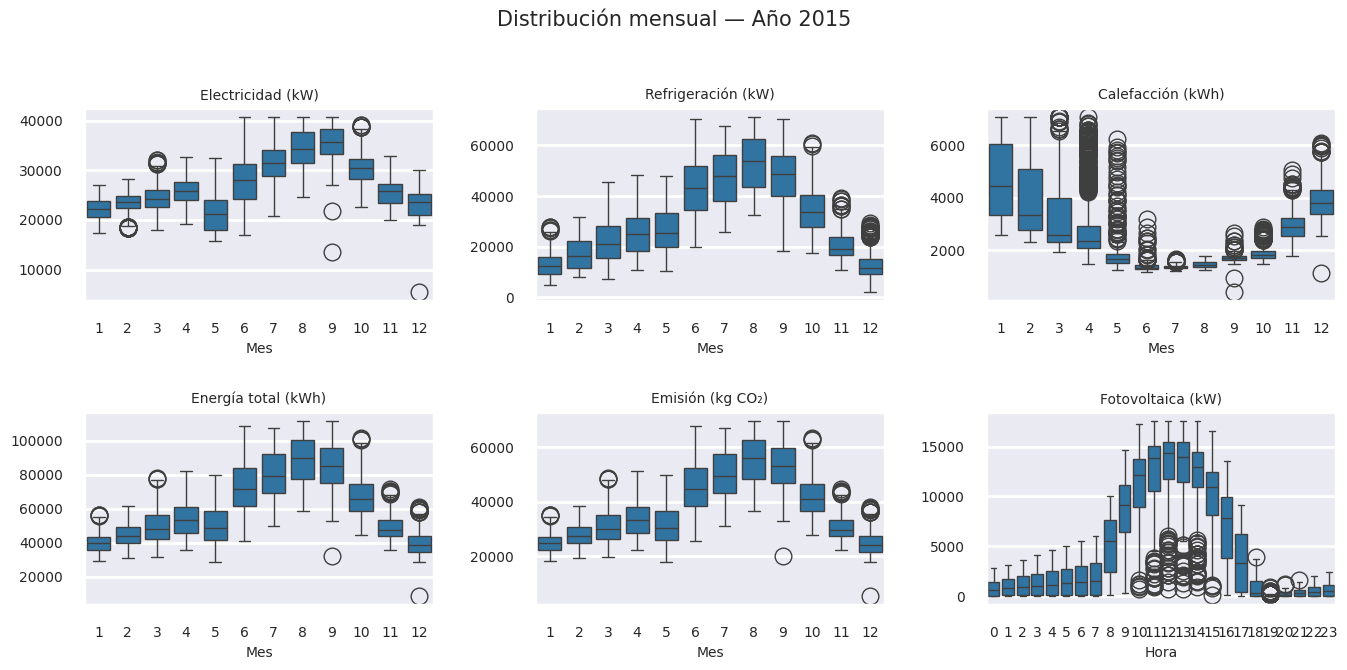

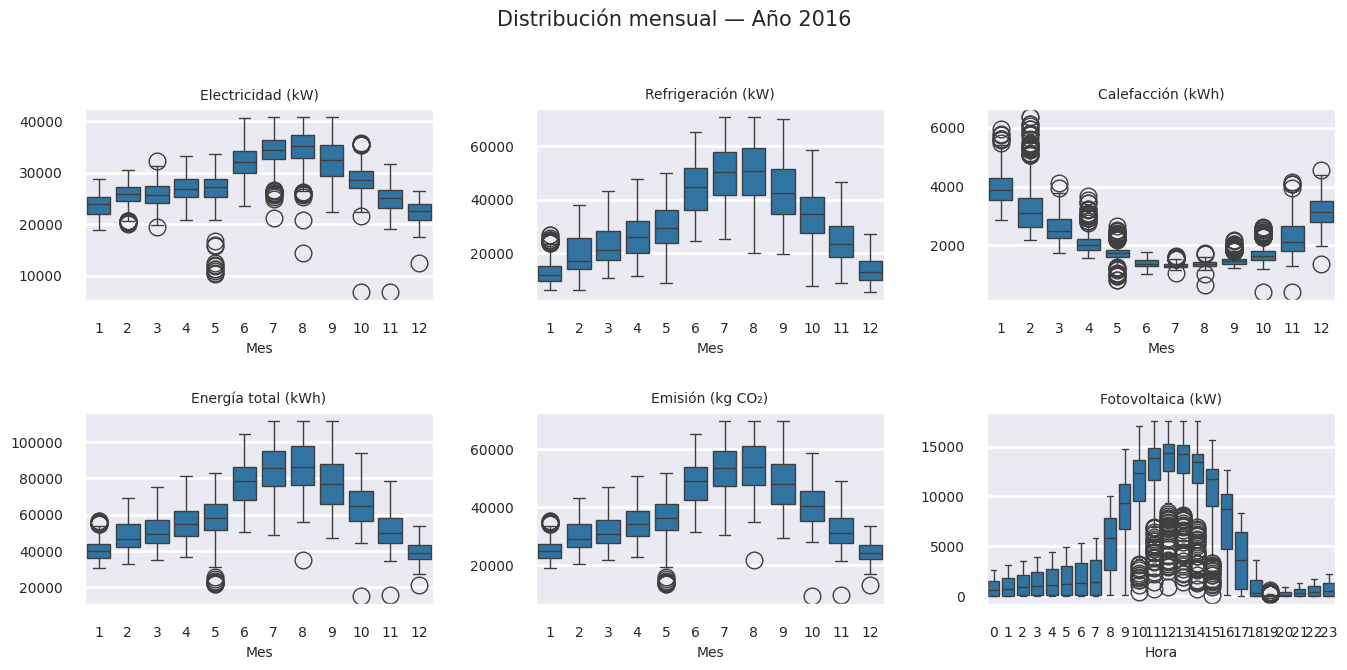

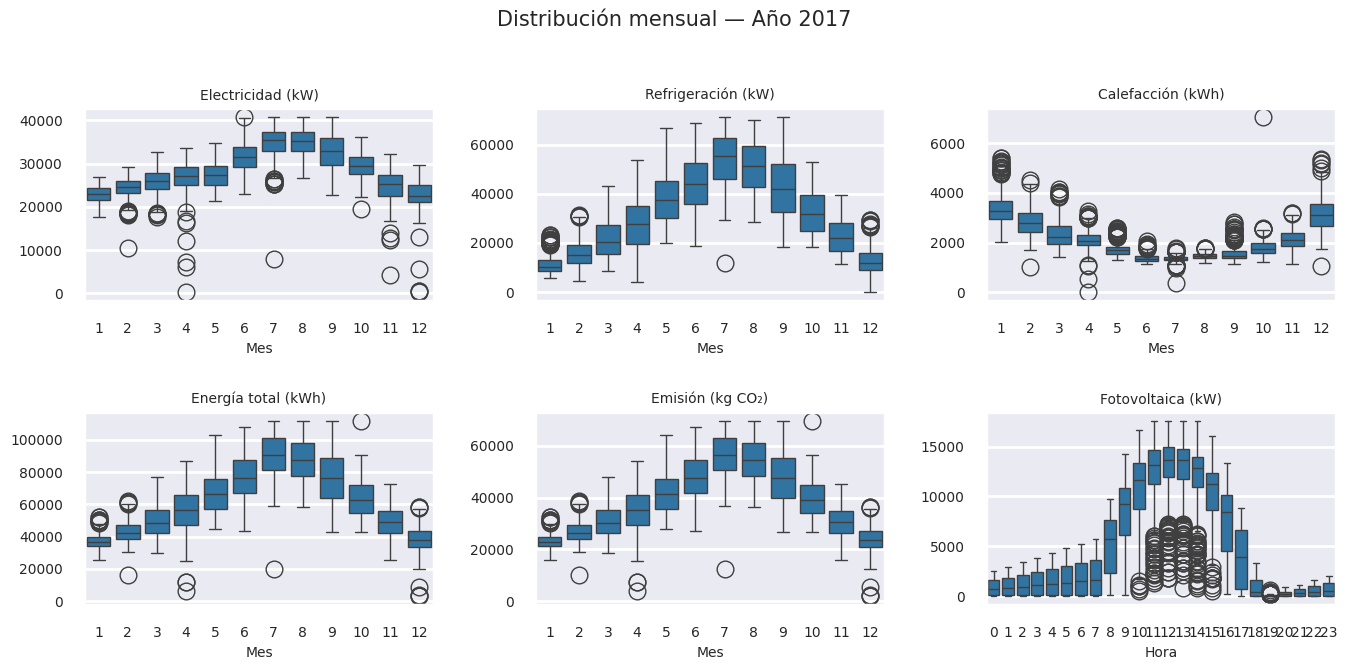

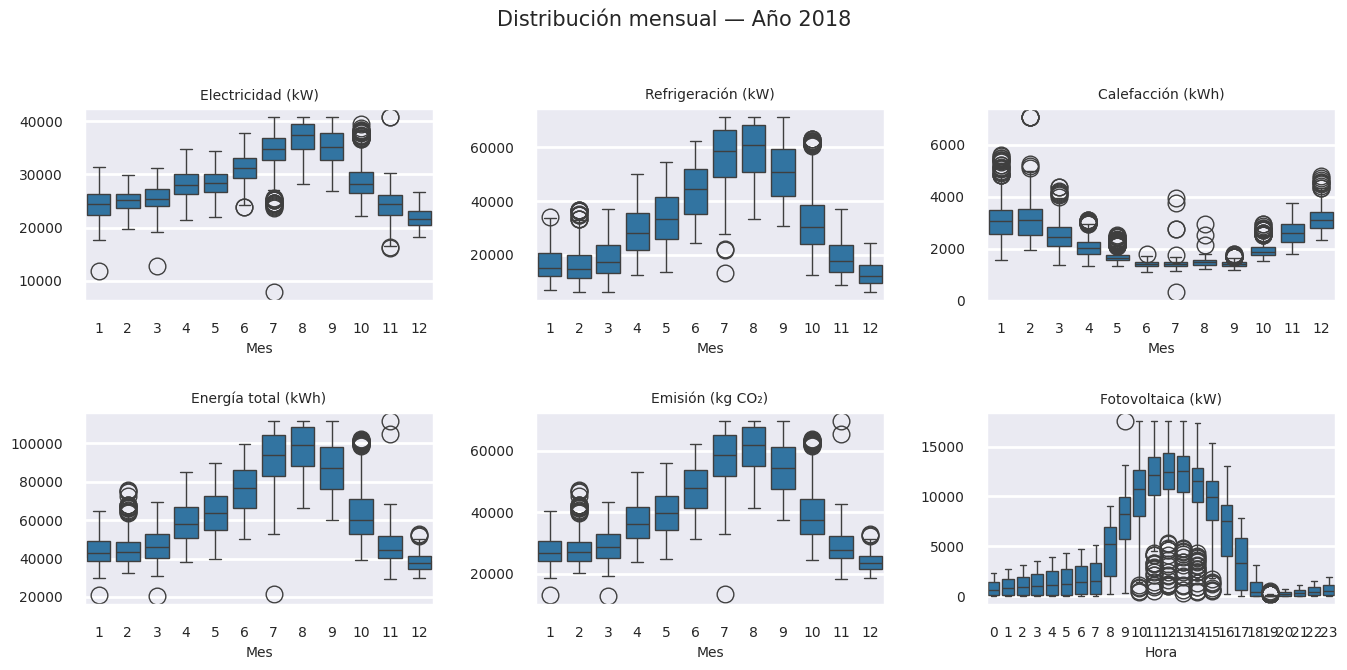

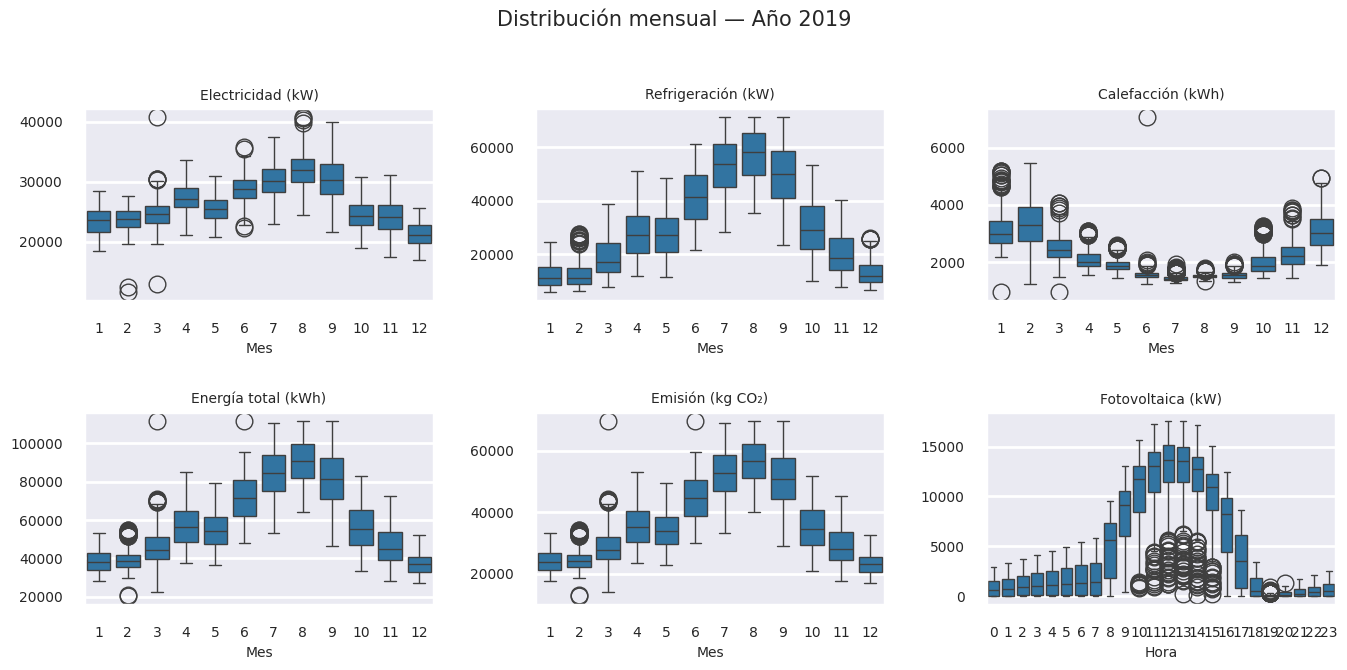

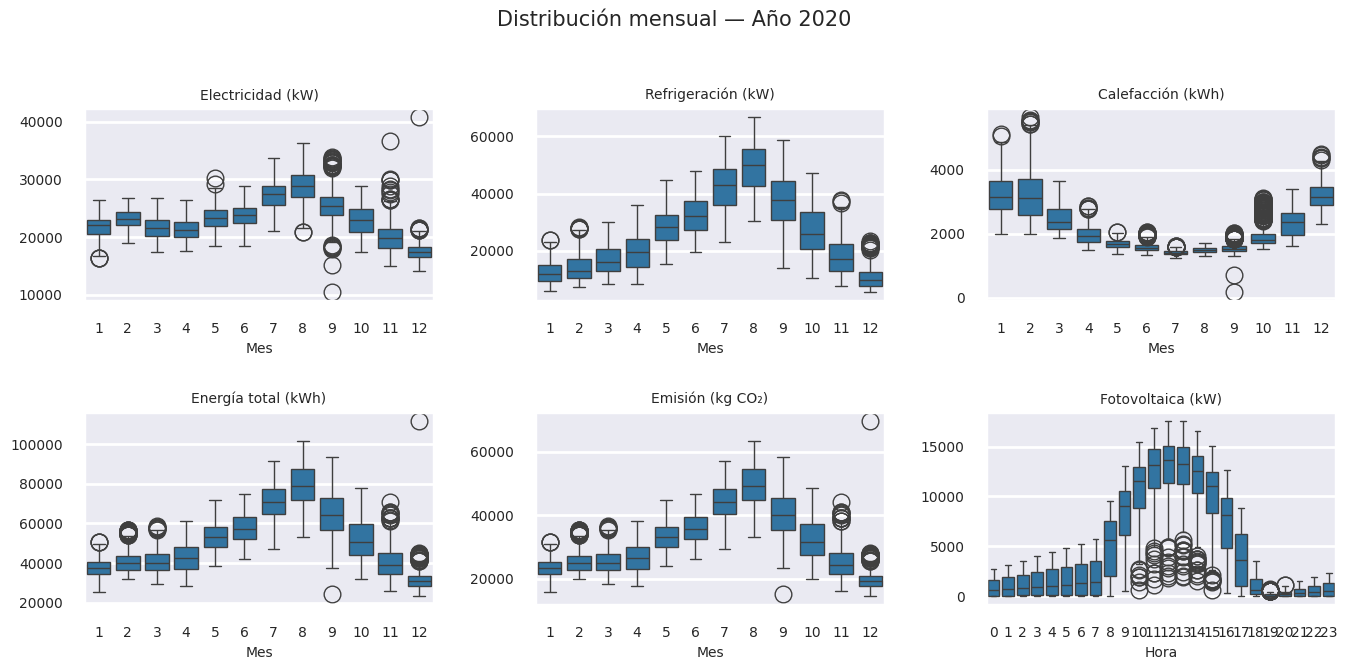

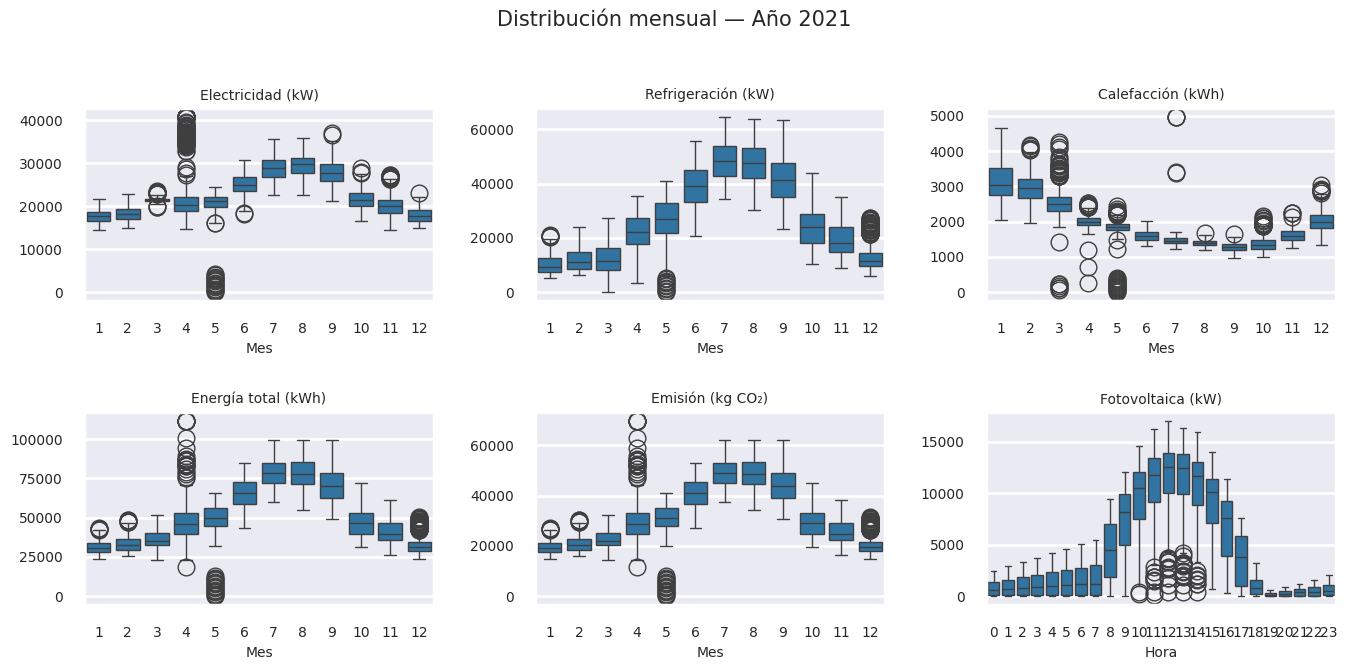

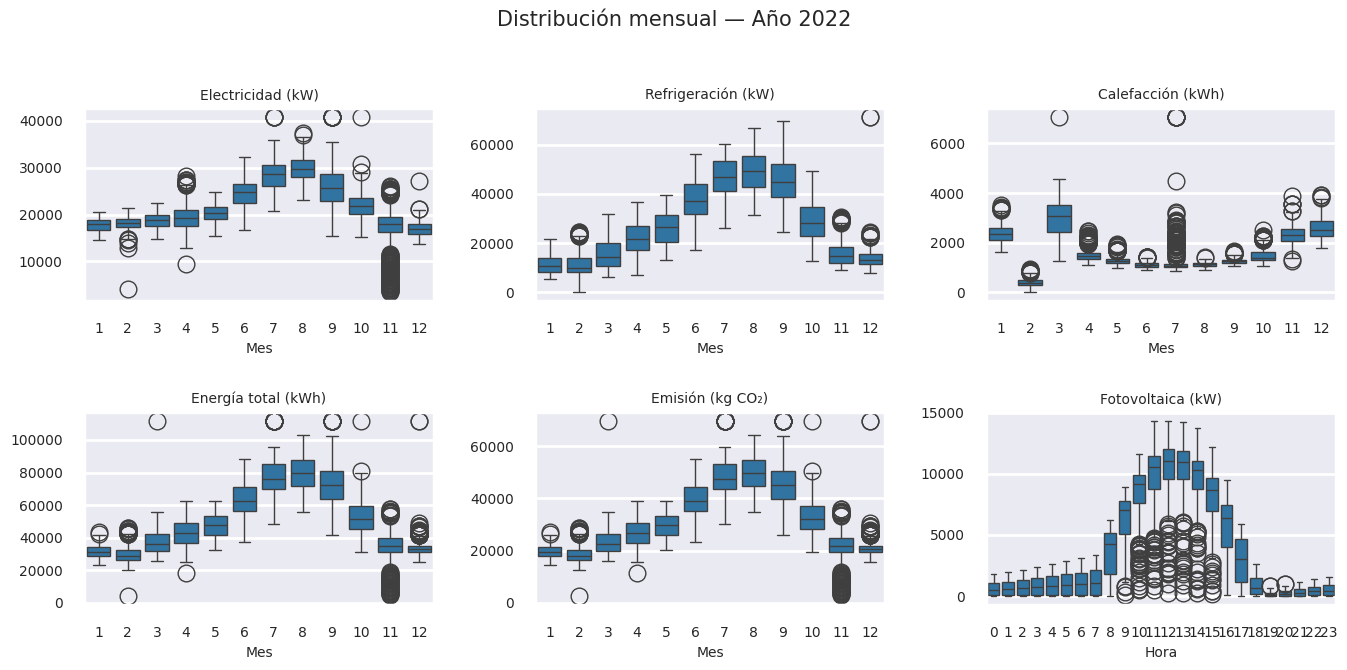

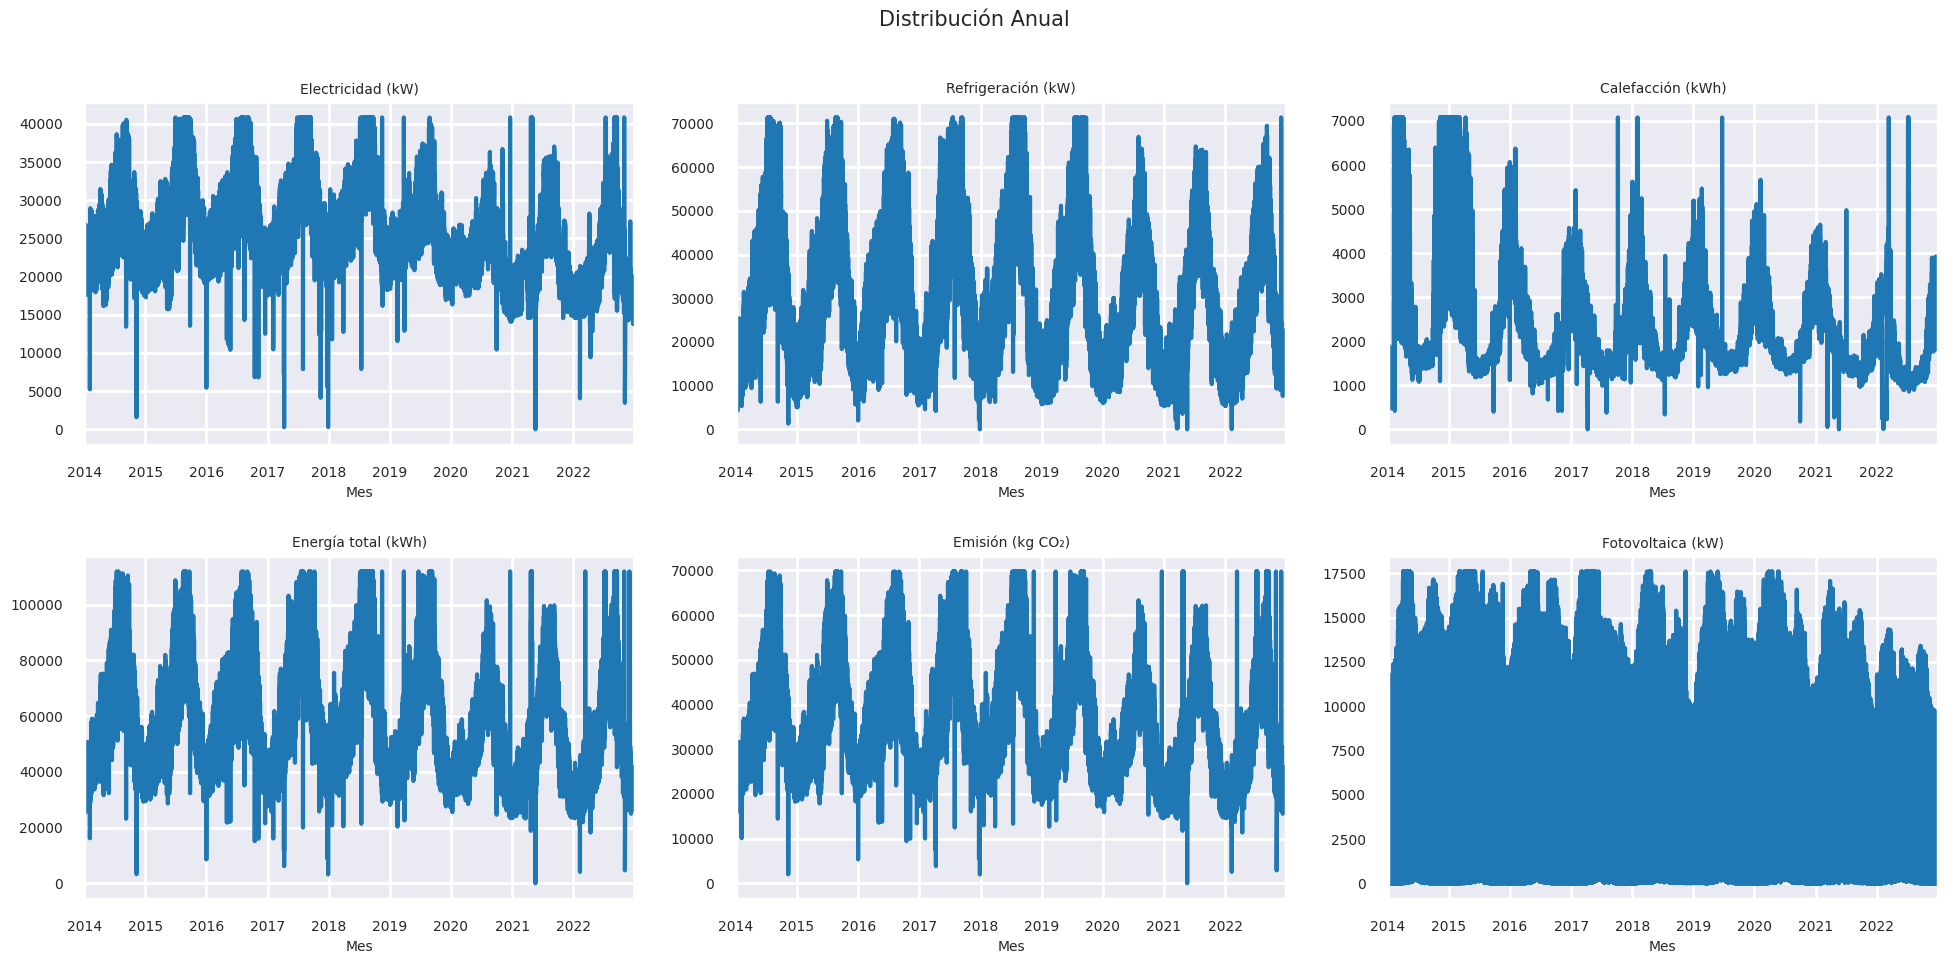

In [11]:
for y in anyos:
    datos = energia.loc[energia['Año'] == y]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
    axes = axes.flatten()
    
    for i, col in enumerate(columnas_energia):
        ax = axes[i]
        sns.boxplot(x='Mes', y=col, data=datos, ax=ax, whis=1.5, showfliers=True)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Mes", fontsize=10)
        ax.set_ylabel("")
    ax=axes[-1]
    sns.boxplot(x='Hora', y='Fotovoltaica (kW)', data=datos, ax=ax, whis=1.5, showfliers=True)
    ax.set_title('Fotovoltaica (kW)', fontsize=10)
    ax.set_xlabel("Hora", fontsize=10)
    ax.set_ylabel("")
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(columnas_energia_todas):
    ax = axes[i]
    energia[col].plot(ax=ax,figsize=[20, 10])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Mes", fontsize=10)
    ax.set_ylabel("")


# Título general de la figura
fig.suptitle(f"Distribución Anual", fontsize=15)
fig.tight_layout()
plt.show()

## Remuestreo a frecuencia diaria y agregación por tipo de magnitud

En este paso convertimos la serie horaria `energia` a una serie diaria `energia_d` mediante `resample('D')` y una agregación columna a columna.
El objetivo es homogeneizar la granularidad temporal, reducir ruido y adaptar las variables a una interpretación coherente con sus unidades (potencia vs energía).

### Diccionario de agregación (`agg_map`)

No todas las columnas representan el mismo tipo de magnitud:

- Potencia (kW): es una tasa instantánea (o promedio en intervalos horarios). Para obtener un valor representativo del día, se usa la media diaria.
- Energía (kWh) y Emisiones (kg CO₂): son magnitudes acumulables.  Para pasar de horas a día, se usa la suma diaria, ya que queremos el total consumido/emitido ese día.

In [12]:
agg_map = {
    'Electricidad (kW)': 'mean',      # potencia -> nivel medio diario
    'Fotovoltaica (kW)': 'mean',      # potencia -> nivel medio diario
    'Refrigeración (kW)': 'mean',     # potencia -> nivel medio diario
    'Calefacción (kWh)': 'sum',       # energía -> suma diaria
    'Energía total (kWh)': 'sum',     # energía -> suma diaria (objetivo)
    'Emisión (kg CO₂)': 'sum'         # emisiones -> suma diaria
}
energia_d = energia.resample('D').agg(agg_map)
energia_d.insert(loc=0, column='Día de la semana', value=energia_d.index.dayofweek)

display(energia_d)

,Día de la semana,Electricidad (kW),Fotovoltaica (kW),Refrigeración (kW),Calefacción (kWh),Energía total (kWh),Emisión (kg CO₂)
fecha,,,,,,,
2014-01-01,2,20418.720000,2615.131528,10140.404904,20107.60131,753514.84810,469960.0
2014-01-02,3,23186.940000,2679.808611,13495.252154,23987.86135,904352.63038,564020.0
2014-01-03,4,22742.977083,2800.490486,14041.858432,22112.20695,904944.63380,564390.0
2014-01-04,5,21312.315000,1950.445694,10520.544245,21074.73561,785049.28770,489640.0
2014-01-05,6,20950.283333,2923.744306,10386.057096,22777.47812,774844.55548,483270.0
...,...,...,...,...,...,...,...
2022-12-27,1,16016.080417,1255.032708,14269.371697,53687.67649,780530.13288,486790.0
2022-12-28,2,15897.035833,225.643750,12713.084543,53895.75690,740525.94138,461820.0
2022-12-29,3,16444.640417,818.169792,13037.885354,60730.17262,768306.14147,479160.0


## Visualización comparativa por año: serie horaria/diaria con doble eje (izquierda/derecha)

Este bloque genera, para cada año incluido en `anyos`, una figura compuesta por una rejilla de subgráficos donde se compara la evolución temporal de cada variable energética en dos escalas temporales:

- Serie horaria (`energia`) representada en el eje Y izquierdo (color azul).
- Serie diaria agregada (`energia_d`) representada en el eje Y derecho (color rojo).

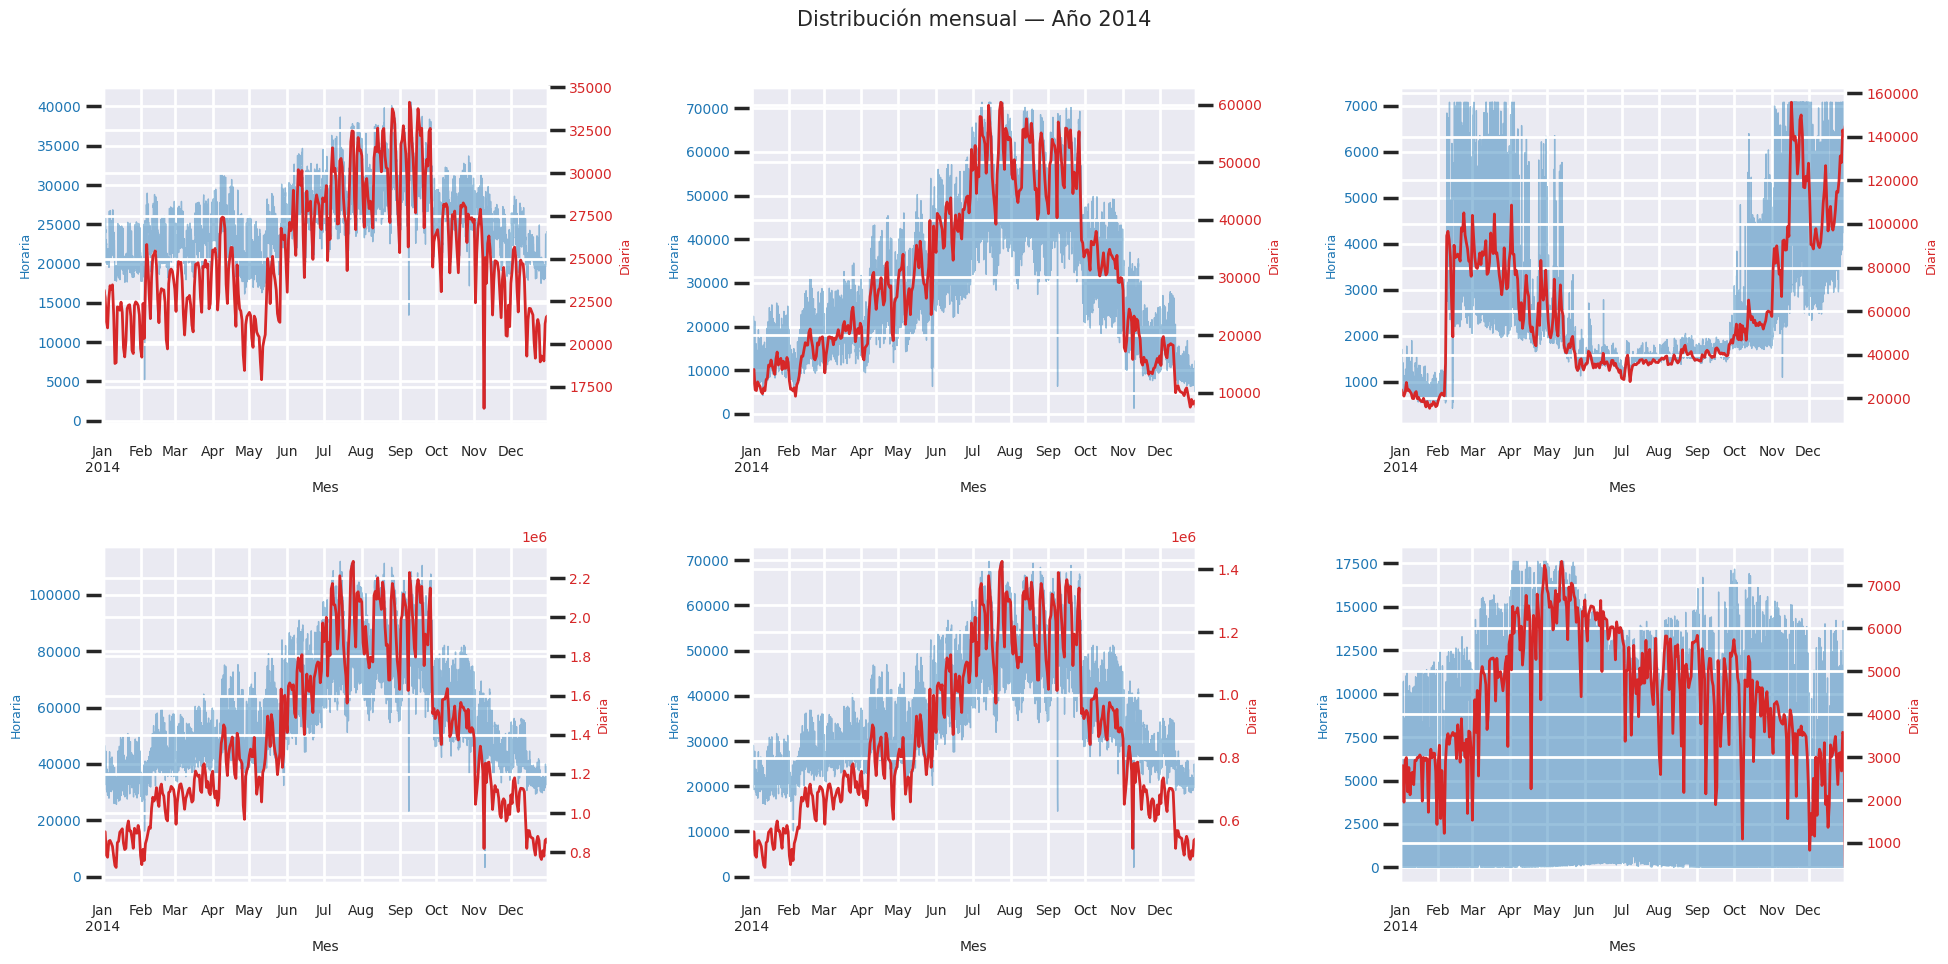

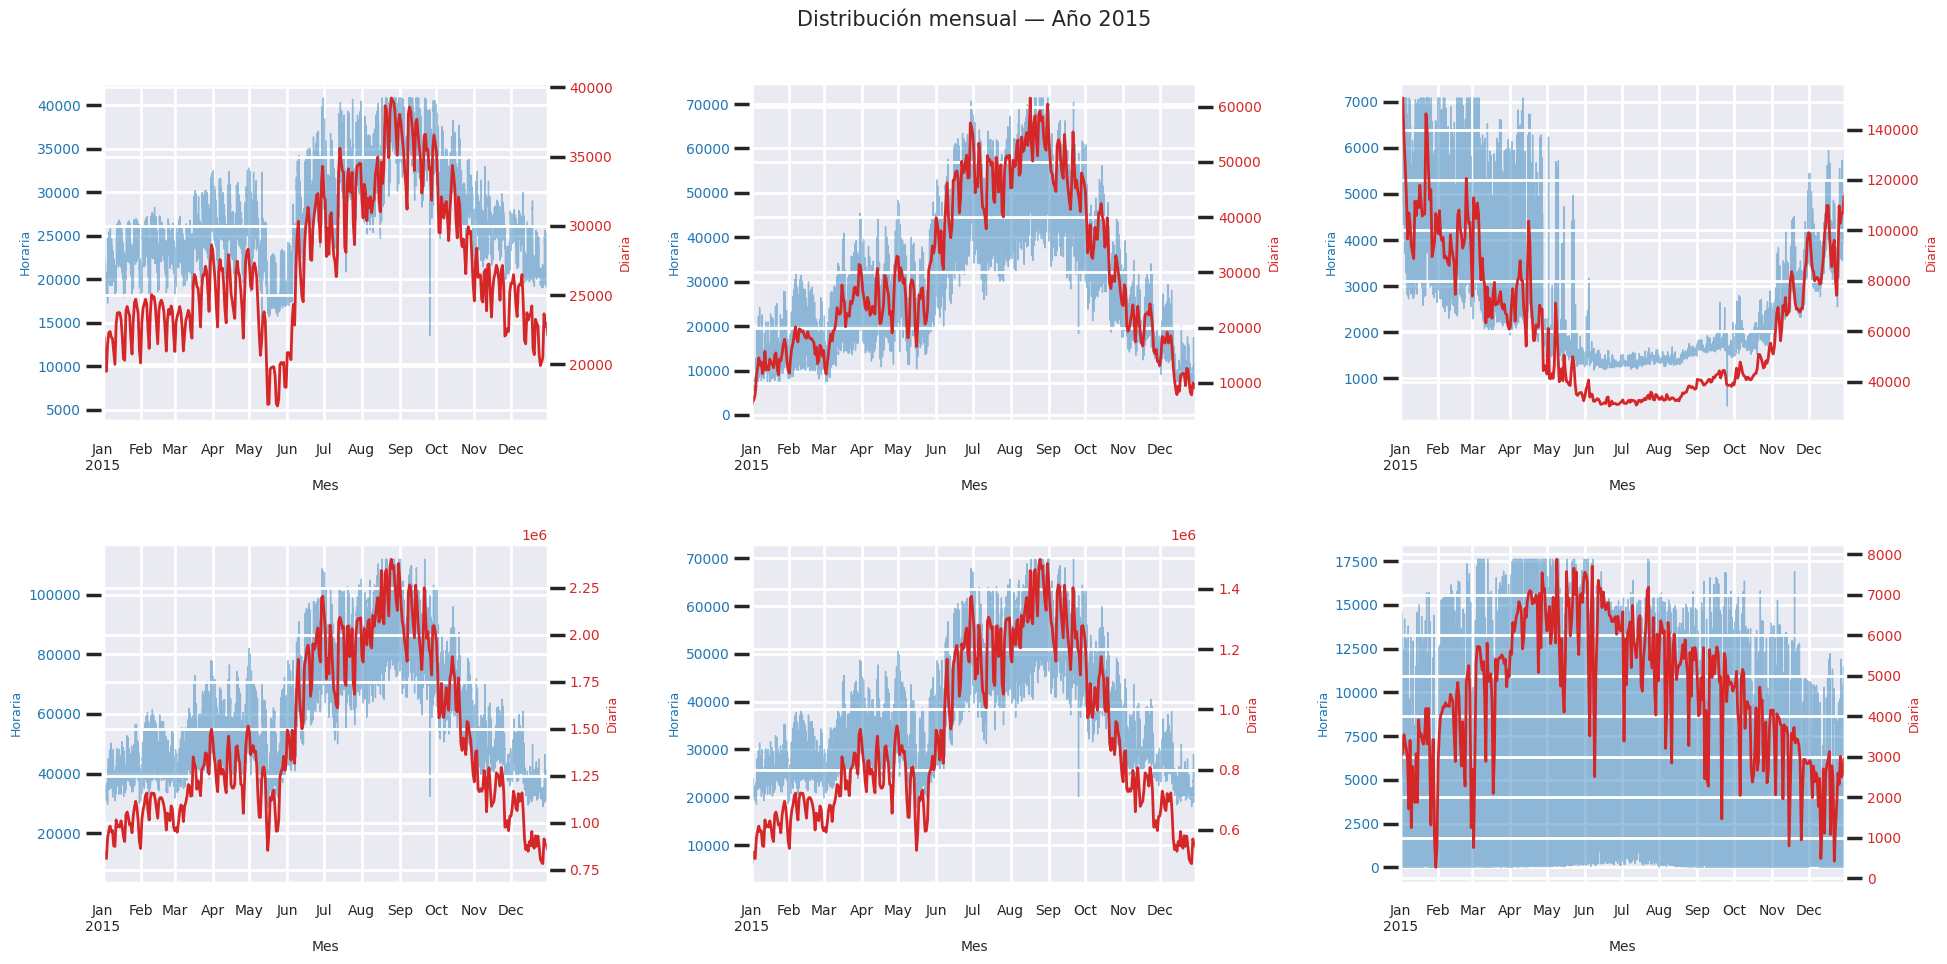

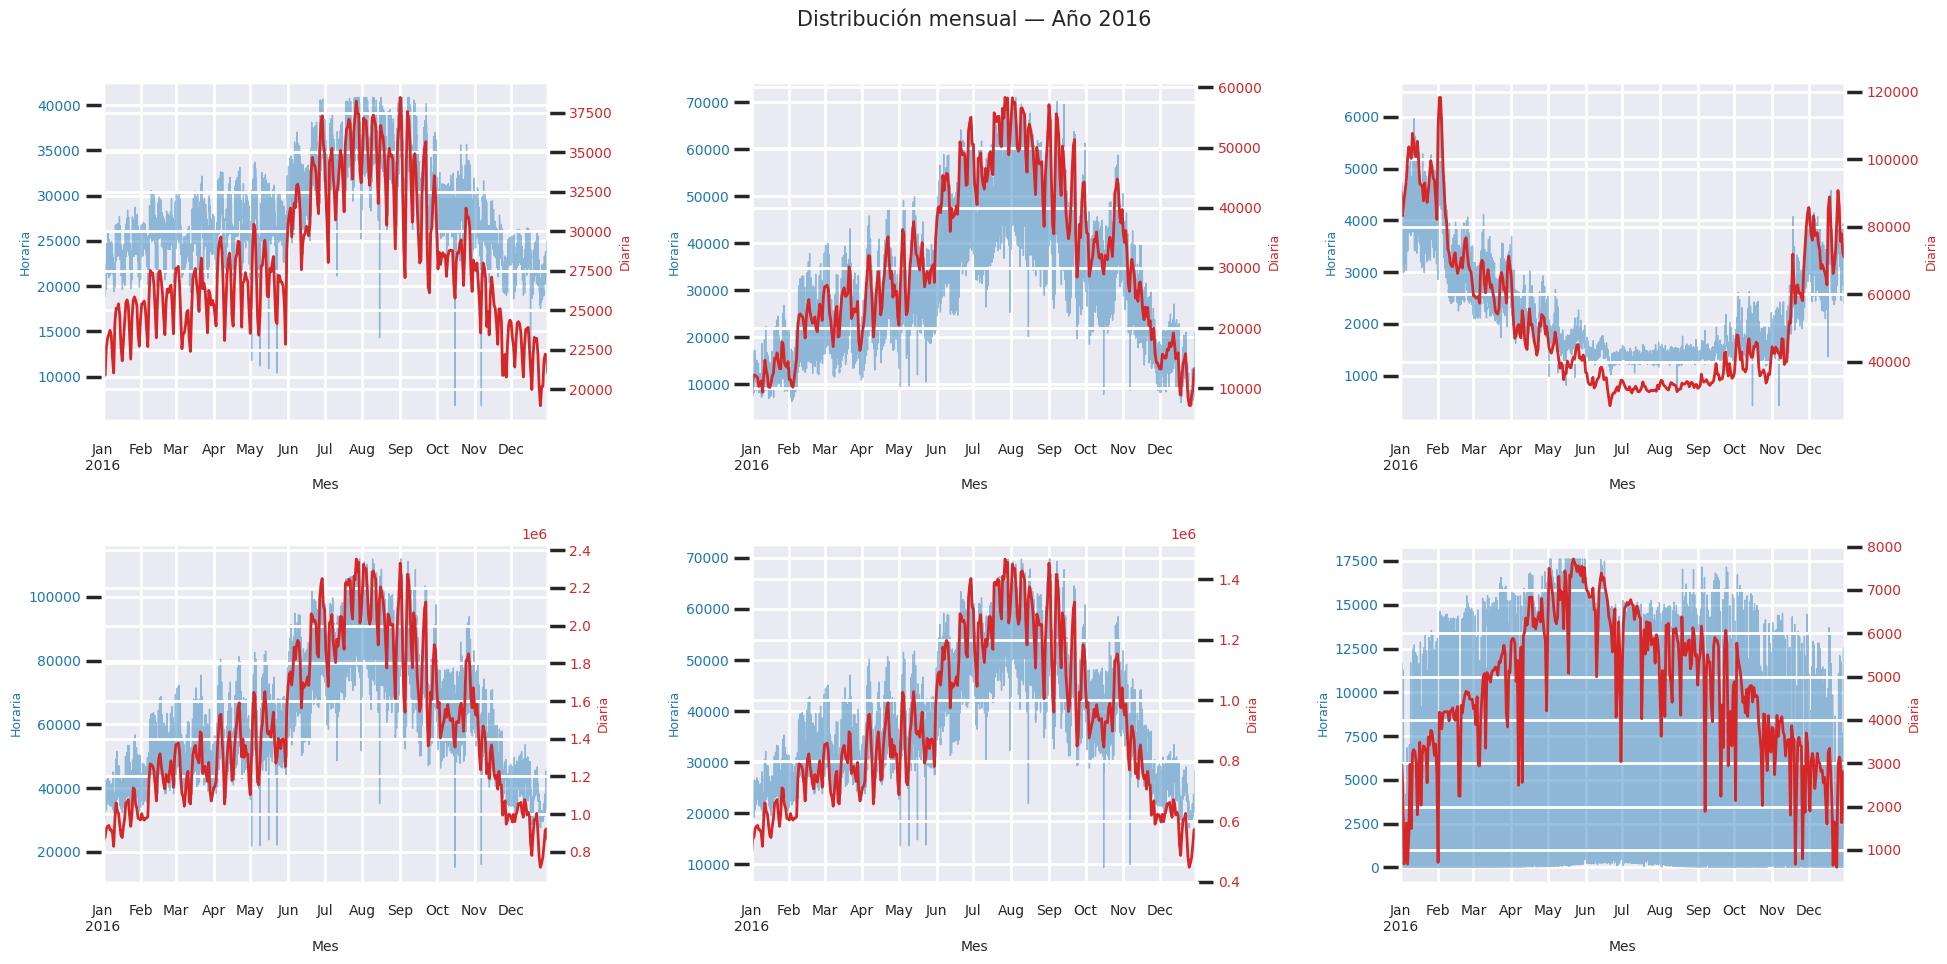

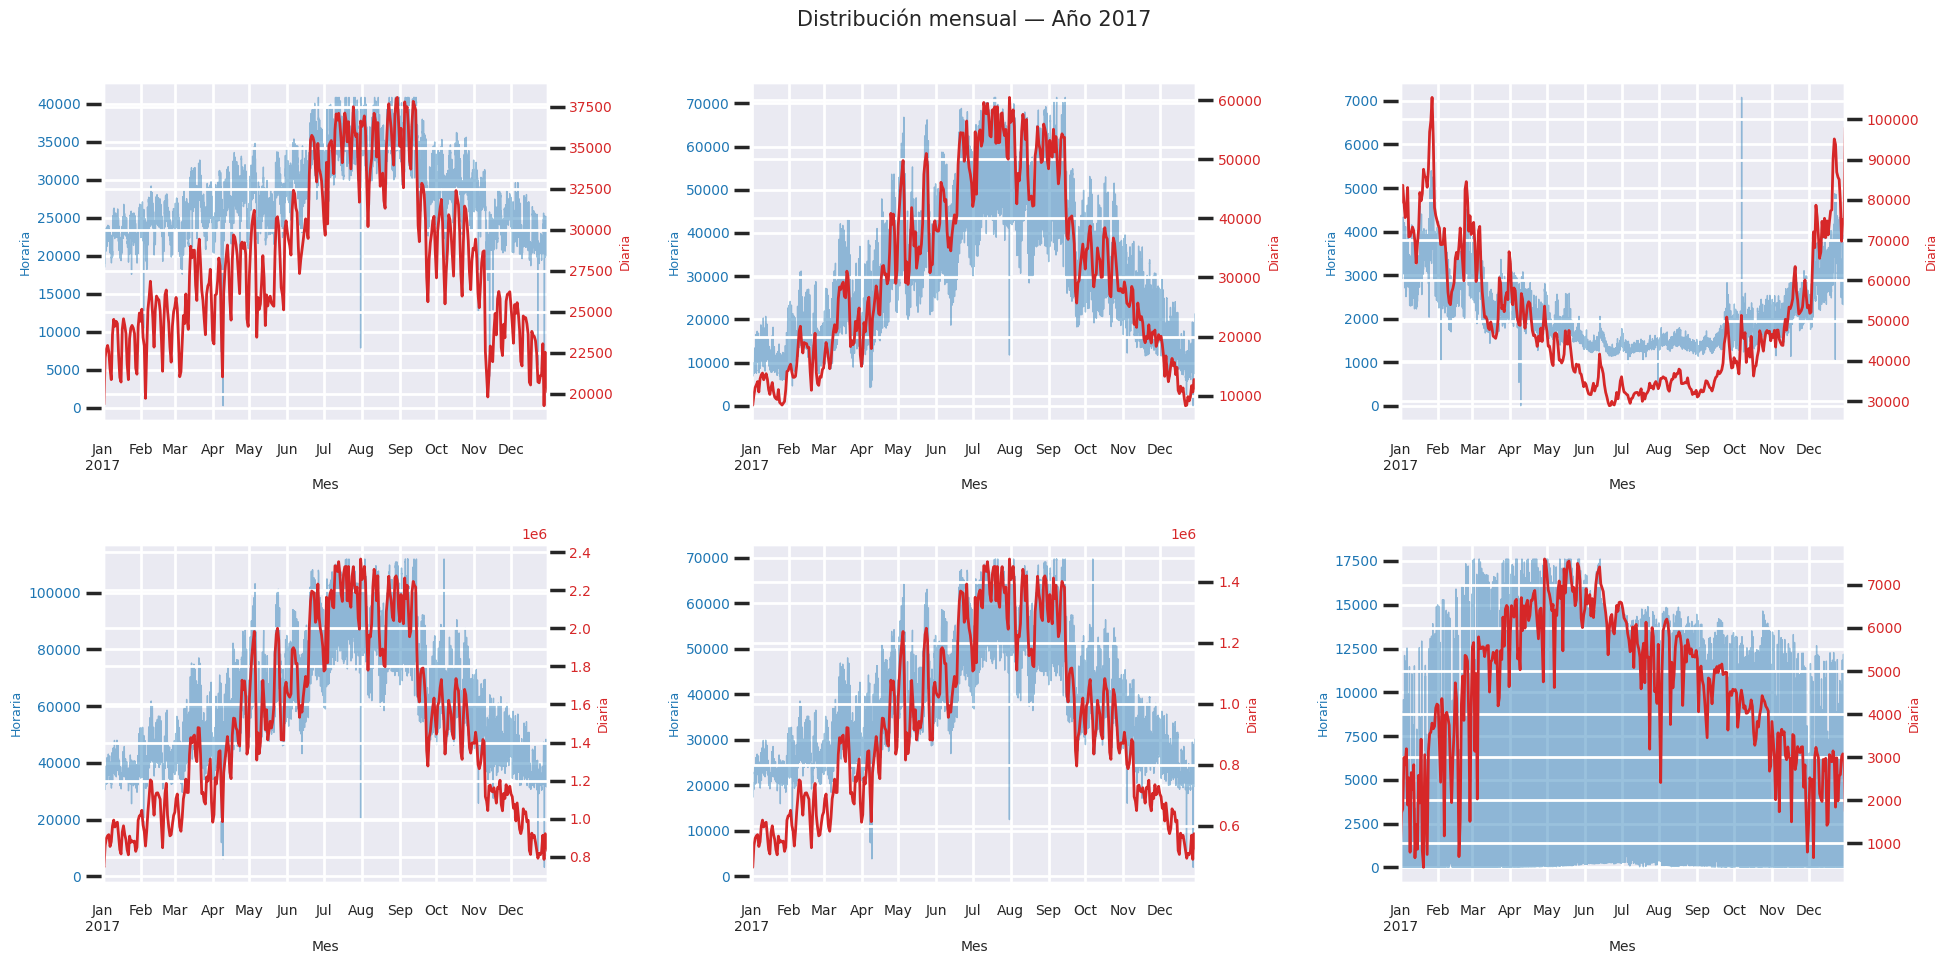

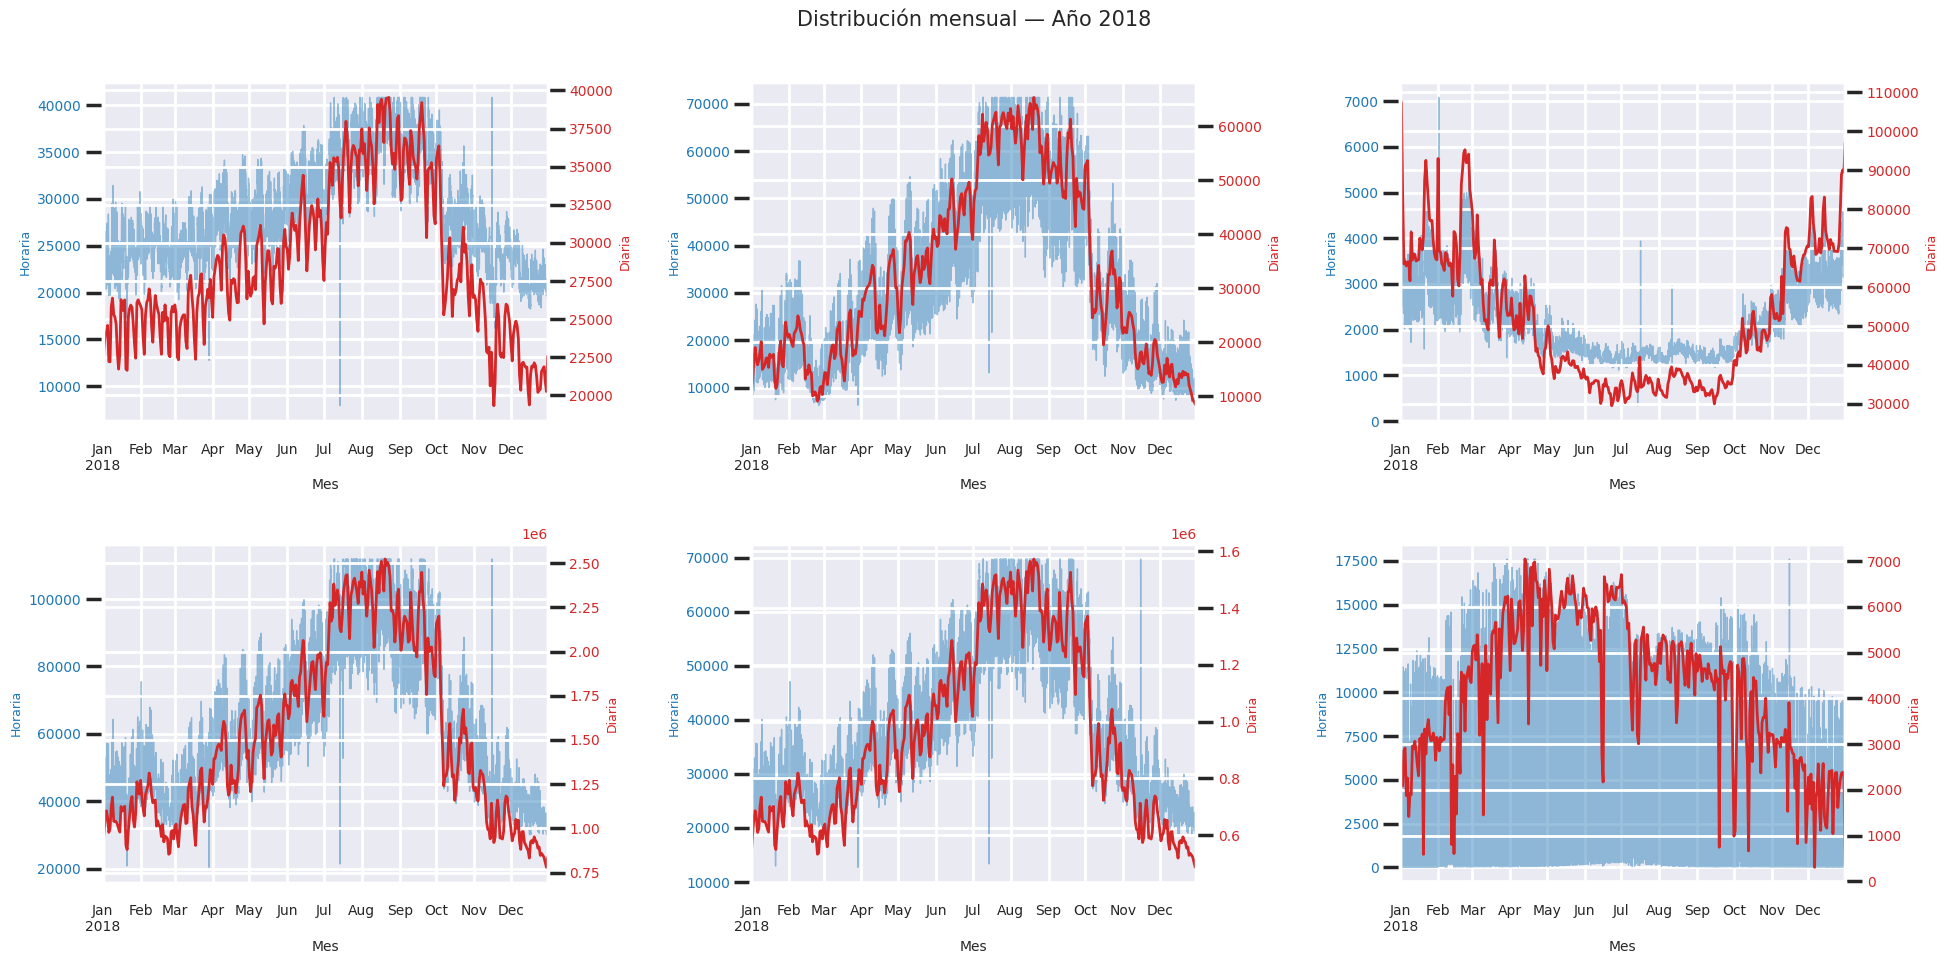

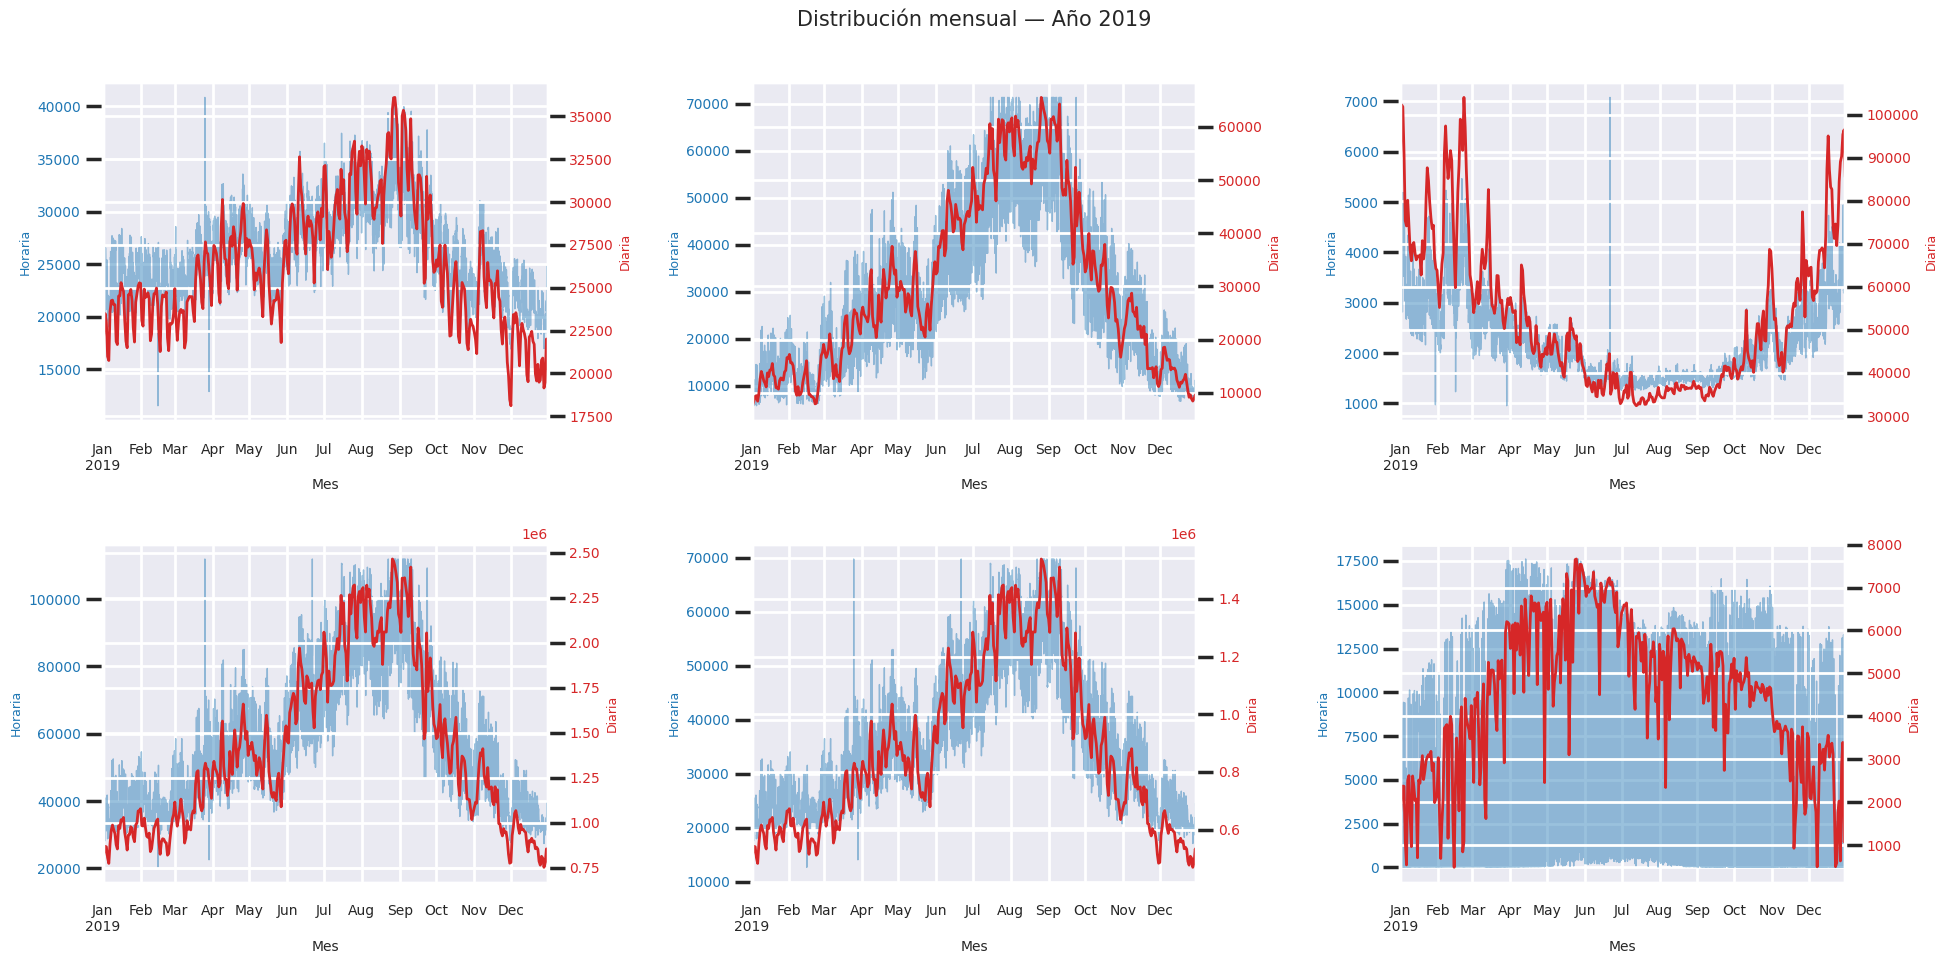

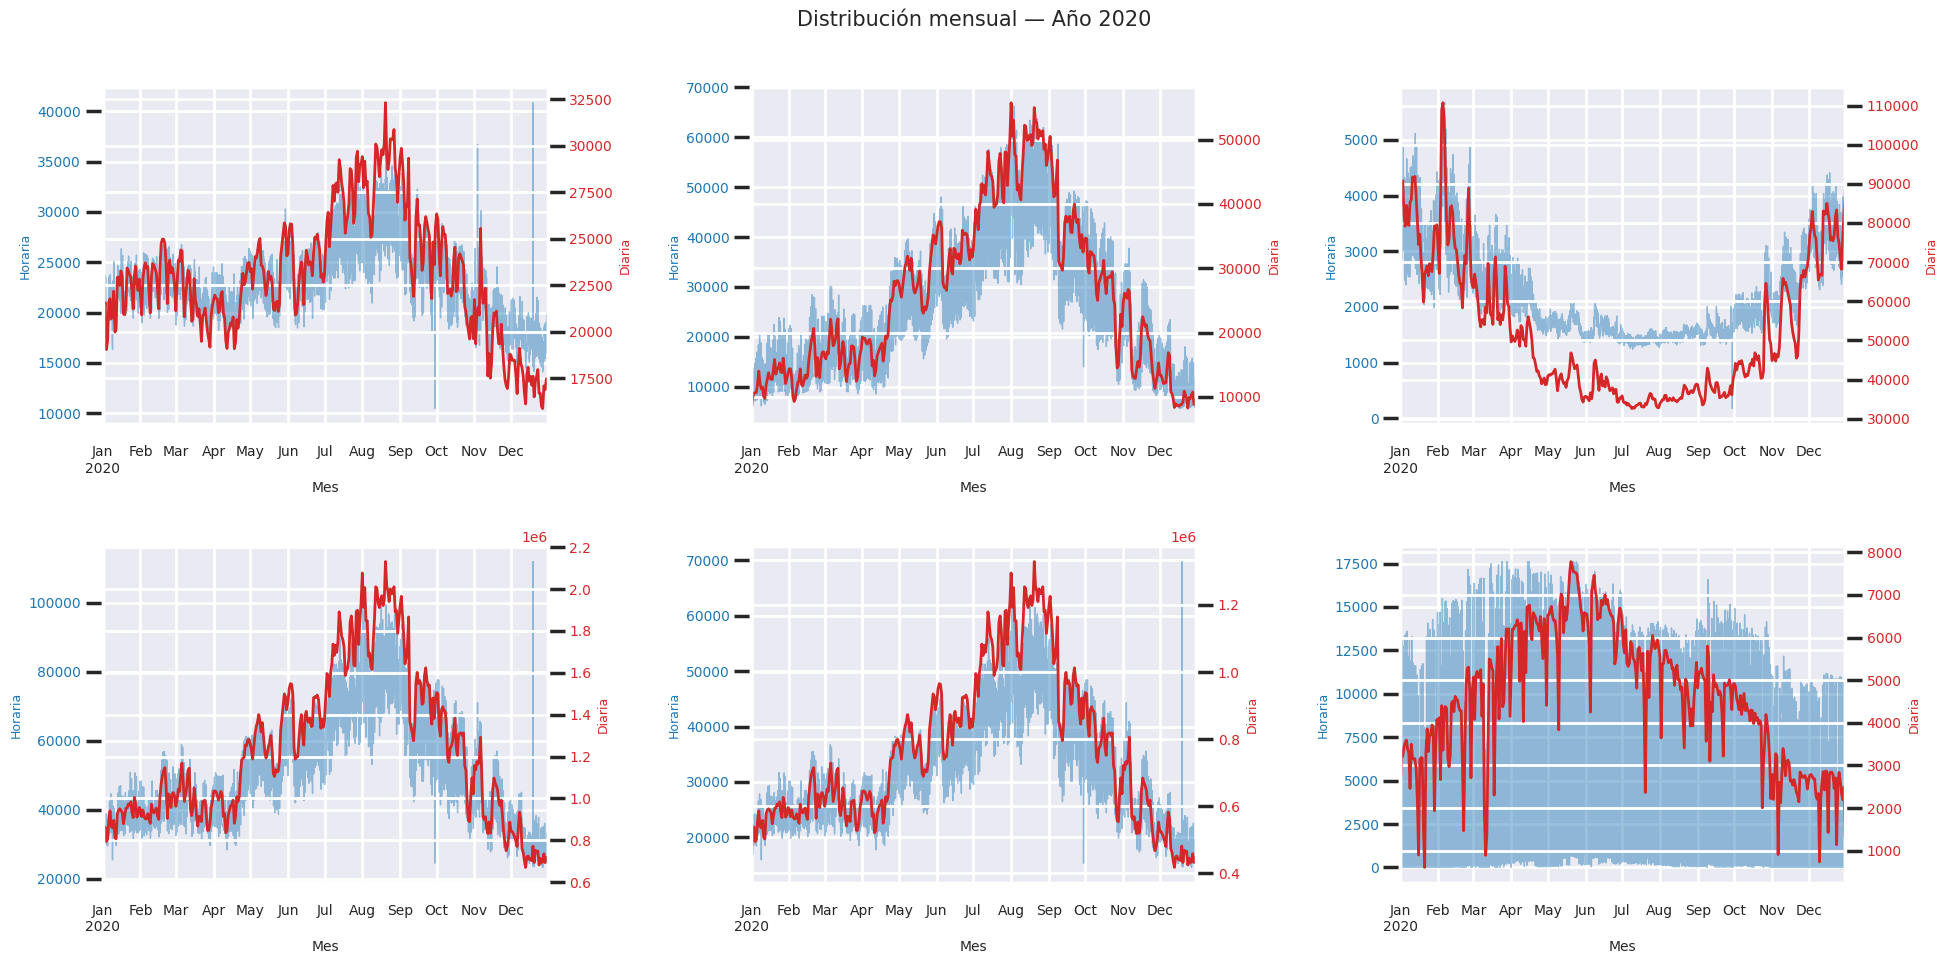

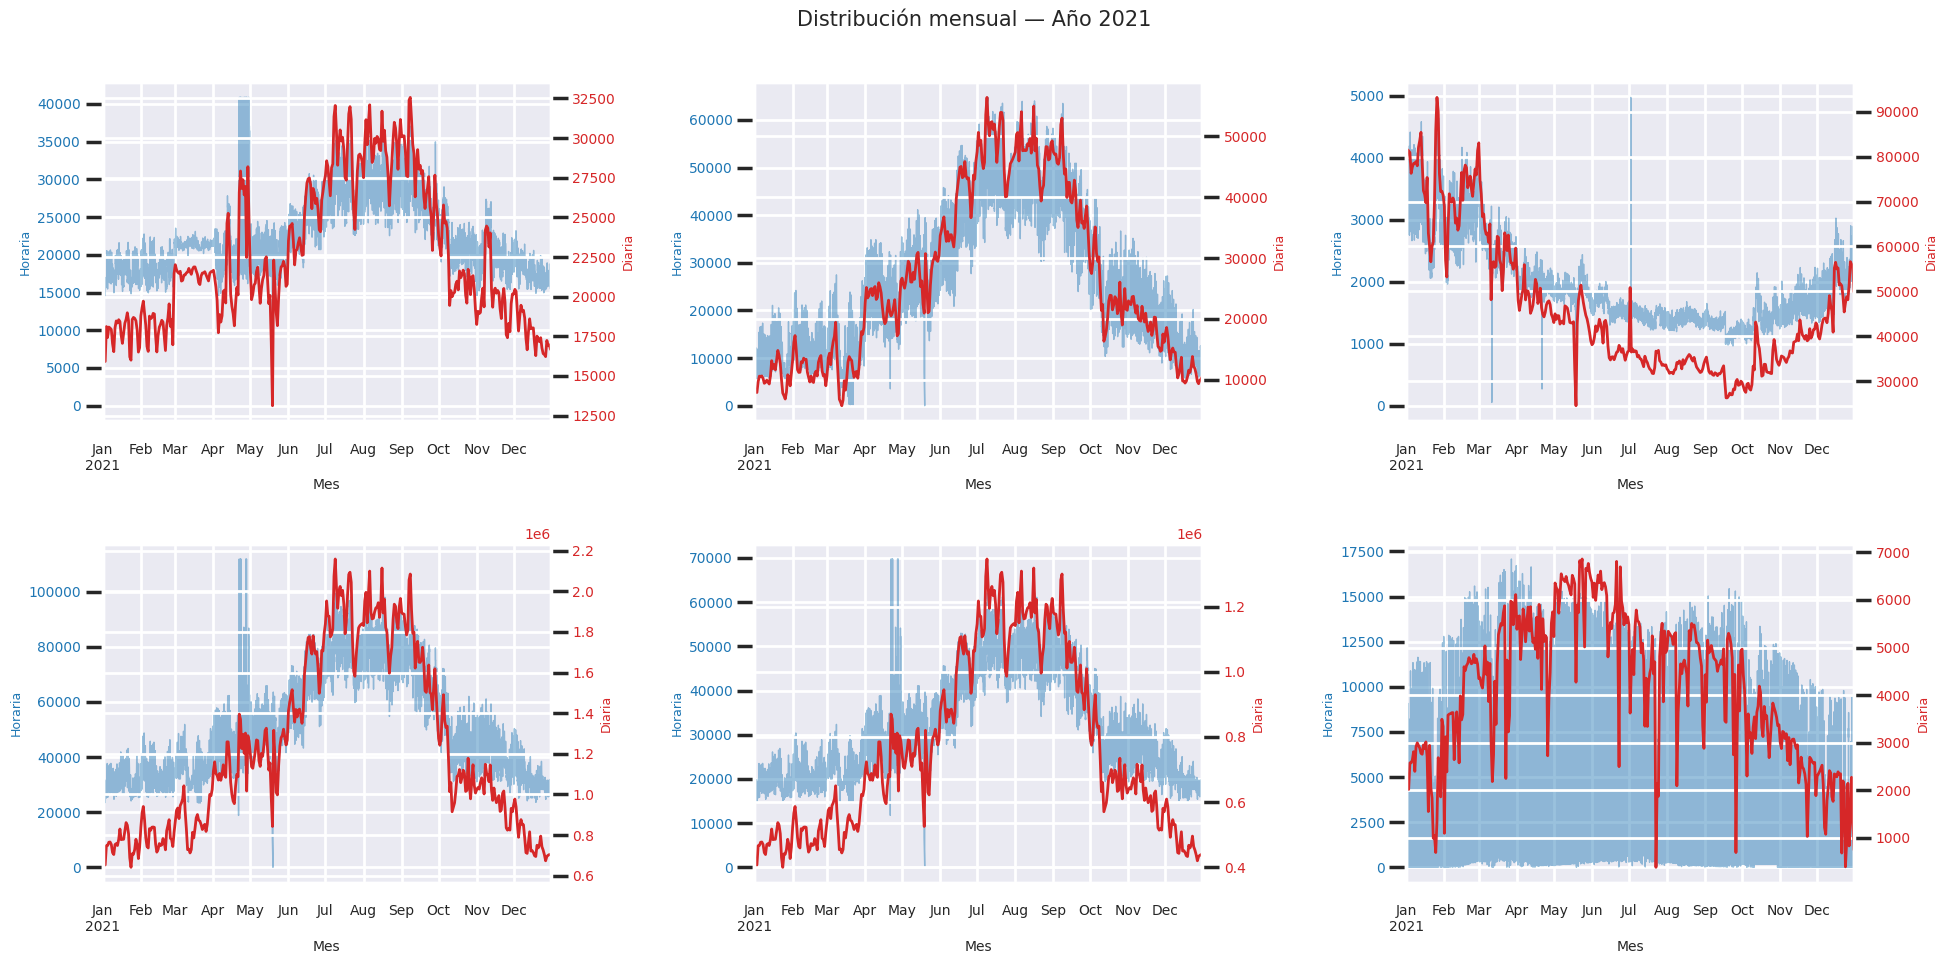

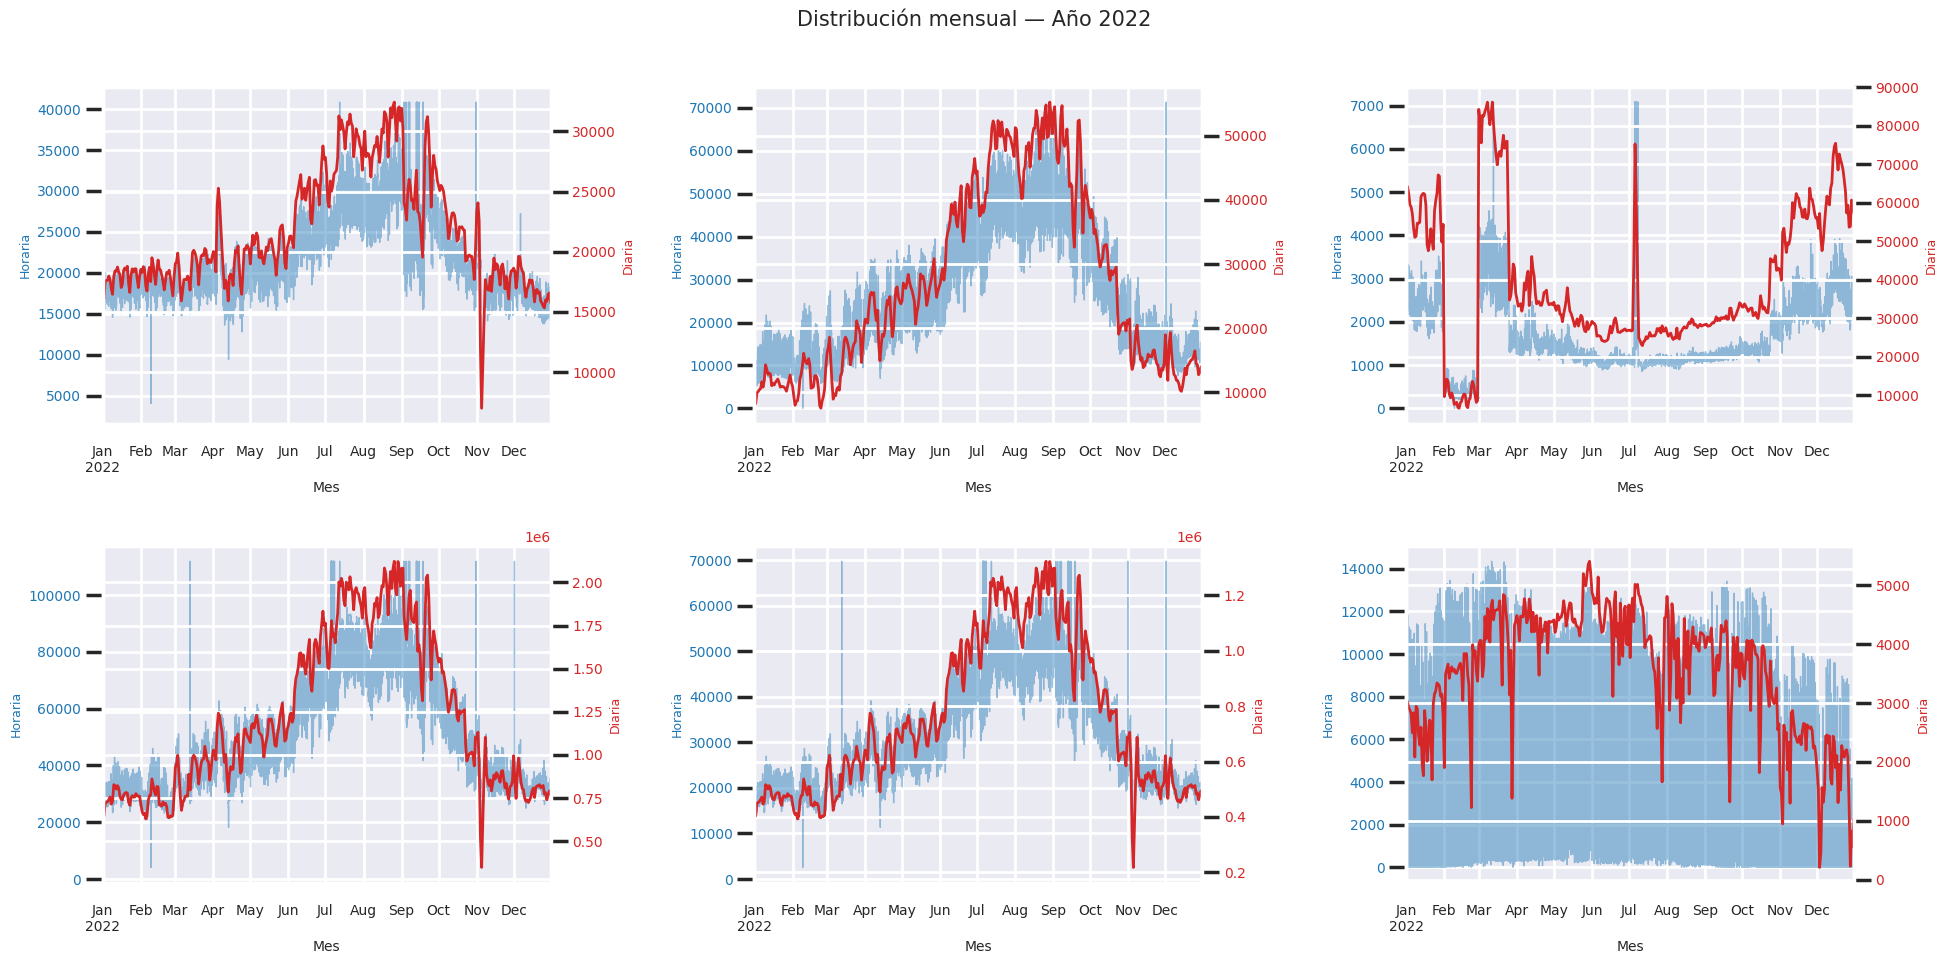

In [13]:
for y in anyos:
    datos = energia.loc[energia.index.year == y]
    datos_d = energia_d.loc[energia_d.index.year == y]

    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(columnas_energia_todas):
        ax = axes[i]
        
        datos[col].plot(ax=ax, color='tab:blue', alpha=0.45, linewidth=1.0, label=f'{col} (horaria)')
        
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax.set_ylabel('Horaria', color='tab:blue', fontsize=9)

        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.set_xlabel("Mes", fontsize=10)

        ax2 = ax.twinx()
        datos_d[col].plot(ax=ax2, color='tab:red', linewidth=2.0, label=f'{col} (diaria)')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax2.set_ylabel('Diaria', color='tab:red', fontsize=9)
    
    # Título general de la figura
    fig.suptitle(f"Distribución mensual — Año {y}", fontsize=15)
    fig.tight_layout()
    plt.show()


# Datos de consumo de energía: Modelos predictivos univariantes

En esta sección, se desarrollarán modelos predictivos univariantes para la predicción en un horizonte temporal de 7 días de la energía total consumida. En el análisis y documentación del proceso se debe, entre otras cuestiones, justificar:

Los modelos de predicción seleccionados (se utilizarán como mínimo 3 técnicas en cada parte de la tarea y 3 métricas). La técnica de remuestreo utilizada. La parrilla de hiperparámetros considerada. Las métricas de evaluación utilizadas. Las preguntas que se deben responder en este apartado son las siguientes:

¿Cuál es el modelo univariante que mejor predice el consumo de energía total en un horizonte de 7 días? ¿Cómo se ha realizado el ajuste de parámetros en las técnicas? ¿Cuál ha sido la metodología para elegir los parámetros? ¿Cuál es el error cometido por el modelo seleccionado en el punto anterior? y ¿Cómo evoluciona este error a medida que aumenta el horizonte de predicción? ¿Cuáles son las variables más importantes en la predicción? ¿Cambia dicha importancia a medida que aumenta el horizonte temporal? ¿Cómo se ha realizado la comparativa entre técnicas? ¿Qué criterios se han seguido para elegir la mejor opción?

Objetivo

El objetivo de este ejercicio es desarrollar modelos predictivos univariantes para la predicción del consumo de energía total (kWh) en un horizonte temporal de 7 días (168 horas), utilizando exclusivamente la información histórica de la propia serie temporal y la librería skforecast.

## Preparación de la serie diaria objetivo y configuración de horizonte y lags

Se define la serie temporal diaria que se desea predecir
Se realiza una partición cronológica train/test y se establece la configuración del problema de predicción: horizonte de 7 días y conjunto de retardos "lags" para capturar dependencias temporales.

Configuración general del experimento
 * Variable objetivo: Energía total (kWh)
 * Frecuencia temporal: Horaria
 * Horizonte de predicción: 7 días
 * Periodo de entrenamiento: 2014–2021
 * Periodo de test: Año 2022
 * Estrategia multi-step: Enfoque Direct (un modelo independiente por cada horizonte)
 * Técnica de evaluación: Backtesting con ventana de entrenamiento expansiva

Esta configuración permite evaluar el comportamiento de los modelos en un escenario realista de predicción futura, evitando fugas de información.

In [14]:
y = energia_d['Energía total (kWh)'].asfreq('D')
y_train = y.loc[:'2021-12-31']
y_test = y.loc['2022-01-01 00:00':]

steps = 7
lags = list(range(1, 15)) + [7, 14, 21, 28]

## Modelos predictivos univariantes
### Modelos considerados

Se han considerado tres técnicas de regresión:

### Regresión Ridge (modelo lineal regularizado)
Ridge es una regresión lineal con regularización L2, es decir, penaliza coeficientes grandes para reducir la varianza del modelo y mejorar la generalización.
- Actúa como baseline fuerte e interpretable: permite entender de forma sencilla qué retardos contribuyen más (por el peso de sus coeficientes).
- Es especialmente útil cuando existe colinealidad entre *lags* (muy habitual en series diarias: lags cercanos y lags semanales suelen estar correlacionados).
- Suele comportarse bien cuando la dinámica es "suave" y la relación entre pasado y futuro es aproximadamente lineal.
- Ventajas:
  - Rápido de entrenar y estable.
  - Menor riesgo de sobreajuste frente a modelos muy flexibles.
  - Interpretabilidad (coeficientes).
- Limitaciones:
 - Puede quedarse corto si la serie tiene no linealidades fuertes o cambios de régimen.

### Random Forest Regressor (bagging de árboles)
Random Forest es un ensamble de árboles entrenados con bagging: cada árbol se entrena con una muestra distinta y con selección aleatoria de variables. El resultado final es el promedio (regresión), lo que reduce varianza.
- Captura no linealidades y interacciones entre retardos: por ejemplo, “si hace 7 días fue alto y ayer fue bajo, entonces…”.
- Es relativamente robusto frente a ruido y outliers moderados.
- Funciona bien con relaciones complejas sin requerir transformaciones fuertes.
- Ventajas:
  - Buen rendimiento “out-of-the-box”.
  - Menos sensible al escalado de variables.
  - Robusto y estable con suficiente número de árboles.
- Limitaciones:
  - Puede ser menos competitivo que boosting en algunos problemas.
  - No extrapola bien fuera del rango observado (como la mayoría de modelos de árboles).

### Gradient Boosting Regressor (boosting de árboles)
Gradient Boosting construye un ensamble secuencial de árboles: cada nuevo árbol intenta corregir los errores del conjunto anterior. Es un modelo muy potente para capturar patrones no lineales con buen control de sesgo-varianza.
- Suele ser muy competitivo cuando hay patrones complejos y relaciones no lineales entre lags.
- Permite controlar cuidadosamente la complejidad usando árboles poco profundos y una tasa de aprendizaje baja, mejorando la generalización.
-Ventajas:
  - Alta precisión en muchos problemas tabulares.
  - Buen equilibrio entre flexibilidad y control del sobreajuste (si se ajusta bien).
  - Capaz de capturar dependencias sutiles que un modelo lineal no ve.
-Limitaciones:
  - Más sensible a hiperparámetros que Random Forest.
  - Puede sobreajustar si `n_estimators` es alto y `learning_rate` no es adecuado.



Estas técnicas permiten comparar modelos lineales y no lineales manteniendo un nivel de complejidad acorde con los contenidos de la asignatura.

In [15]:
# Modelos
modelos = {
    'Ridge': Ridge(random_state=SEED),
    'RandomForest': RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=SEED)
}

### Backtesting de modelos univariantes con `skforecast` con horizonte 7 días

La evaluación de los modelos se realiza mediante un esquema de validación temporal (backtesting) con ventana de entrenamiento expansiva, utilizando como métricas el MAE, el RMSE y el MAPE.


Se define un objeto TimeSeriesFold que controla cómo se generan los pliegues (folds) de entrenamiento/validación en el backtesting, donde:
 * steps=steps: número de pasos a predecir en cada iteración. En este caso, steps = 7, es decir, 7 días.
 * initial_train_size=len(y_train): el tamaño del entrenamiento inicial coincide con el tramo definido como y_train (hasta 31/12/2021). A partir de ahí, se valida en los periodos posteriores.
 * fixed_train_size=False: la ventana de entrenamiento es expansiva, es decir, a medida que avanza el tiempo se incorporan nuevas observaciones al entrenamiento. Esto es adecuado al disponer de un histórico amplio y se desea aprovechar toda la información acumulada.
 * refit=False: no se re-entrena completamente el modelo en cada fold (reduce coste computacional).
 * gap=0: no se deja separación entre train y validación.
 * allow_incomplete_fold=True: permite ejecutar el backtesting incluso si el último fold no está completamente lleno.
 * verbose=False: muestra información del proceso.

Se ejecuta el backtesting del forecaster usando:
 * y=y: se proporciona la serie completa; el objeto cv decide qué tramo se usa como entrenamiento y qué tramo se evalúa en cada fold.
 * metric=[a,b,c]: se calculan tres métricas:
   * MAE (mean_absolute_error): error absoluto medio.
   * MSE (mean_squared_error): penaliza más los errores grandes.
   * MAPE (mean_absolute_percentage_error): error relativo porcentual.
 * show_progress=True y verbose=False: muestran progreso y detalle del proceso.
 * n_jobs=-1: paraleliza el backtesting.

El resultado:
 * metrics: métricas agregadas del proceso (por fold/por step según configuración).
 * preds: predicciones generadas durante el backtesting (útiles para análisis adicional y gráficos).

In [16]:
resultados_uni = []

cv = TimeSeriesFold(
    steps=steps,
    initial_train_size=len(y_train),
    refit=False,
    fixed_train_size=False,
    gap=0,
    allow_incomplete_fold=True,
    verbose=False
)

for name, est in modelos.items():
    forecaster = ForecasterDirect(estimator=est, lags=lags, steps=steps, n_jobs=-1)

    metrics, preds = backtesting_forecaster(
        forecaster=forecaster,
        y=y,    # se usa la serie completa; cv define el tramo evaluado tras initial_train_size
        cv=cv,
        metric=[mean_absolute_error,
            mean_squared_error,
            mean_absolute_percentage_error],
        n_jobs=-1,
        verbose=False,
        show_progress=False,
    )

    metrics['model'] = name
    resultados_uni.append(metrics)

resultados_uni = pd.concat(resultados_uni, ignore_index=True)
resultados_uni['RMSE'] = np.sqrt(resultados_uni['mean_squared_error'])

In [17]:
display(resultados_uni)

,mean_absolute_error,mean_squared_error,mean_absolute_percentage_error,model,RMSE
0,99245.833639,1.677131e+10,0.088731,Ridge,129504.084455
1,96764.733798,1.650020e+10,0.089343,RandomForest,128453.118251
2,98921.116058,1.678150e+10,0.090753,GradientBoosting,129543.419780
